In [41]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz

np.random.seed(123)
az.style.use("arviz-doc")

In [42]:
howell = pd.read_csv('data/howell.csv', delimiter=';')
howell

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0
...,...,...,...,...
539,145.415,31.127751,17.0,1
540,162.560,52.163080,31.0,1
541,156.210,54.062497,21.0,0
542,71.120,8.051258,0.0,1


In [43]:
howell_over18 = howell[howell.age > 18.0]
howell_over18.age.min()

19.0

<Axes: xlabel='weight', ylabel='height'>

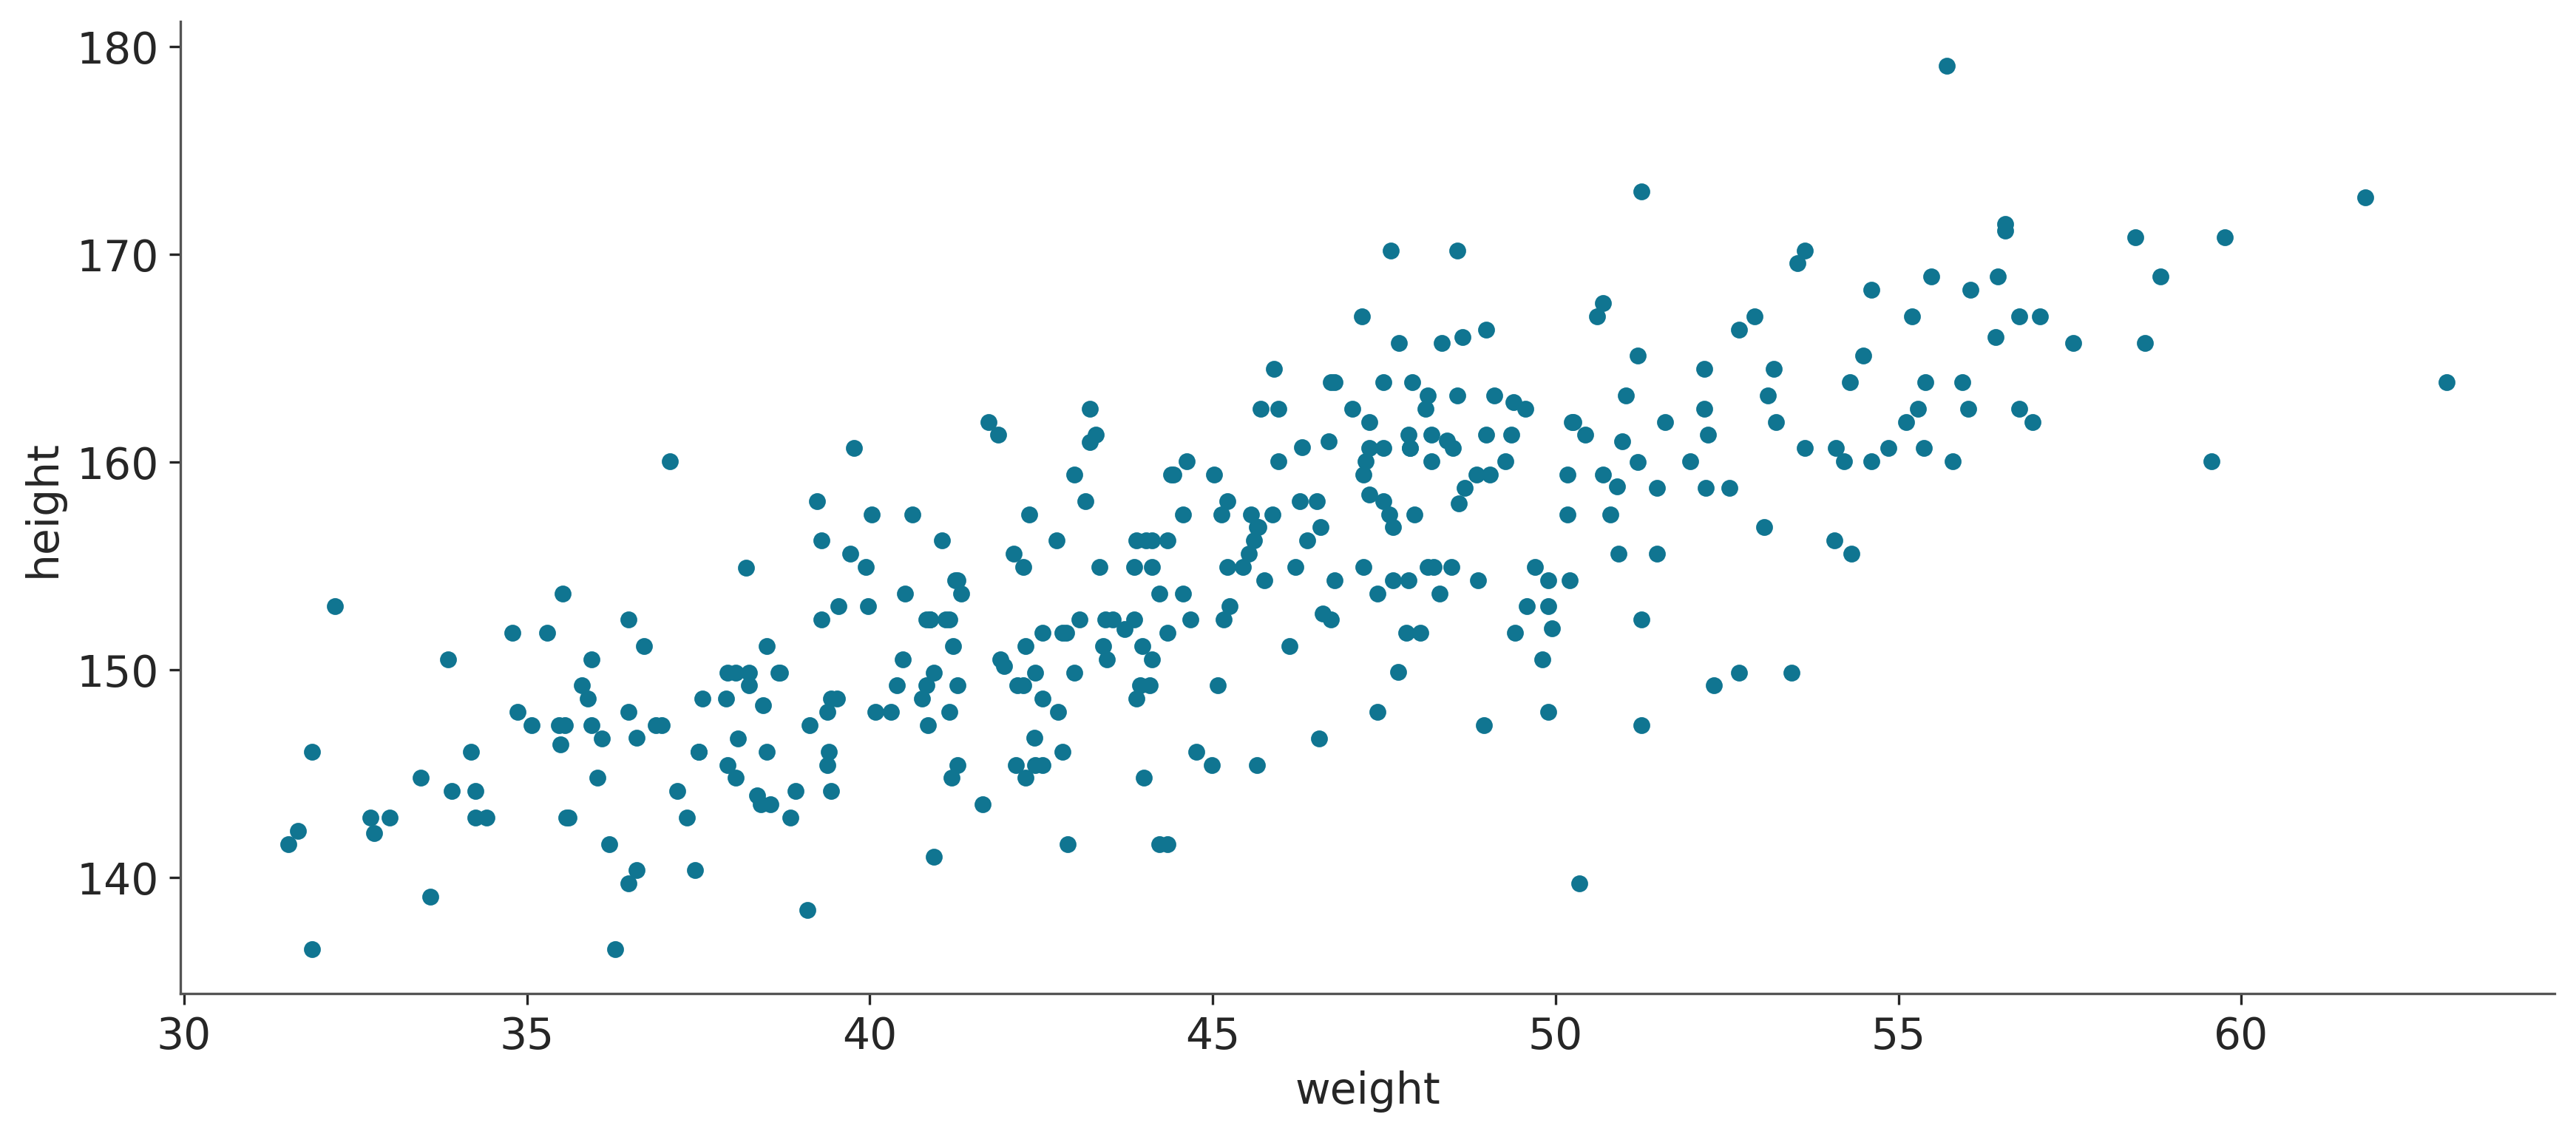

In [44]:
howell_over18.plot(kind='scatter', x='weight', y='height')

In [45]:
mean_weight_age18 = howell_over18.weight.mean()
mean_weight_age18

45.04554285549133

In [46]:
howell_over18.loc[:, "weight_centered"] = howell_over18.weight - mean_weight_age18
howell_over18

/tmp/ipykernel_16039/131566487.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  howell_over18.loc[:, "weight_centered"] = howell_over18.weight - mean_weight_age18


,height,weight,age,male,weight_centered
0,151.765,47.825606,63.0,1,2.780064
1,139.700,36.485807,63.0,0,-8.559736
2,136.525,31.864838,65.0,0,-13.180705
3,156.845,53.041914,41.0,1,7.996372
4,145.415,41.276872,51.0,0,-3.768671
...,...,...,...,...,...
534,162.560,47.031821,27.0,0,1.986278
537,142.875,34.246196,31.0,0,-10.799347
540,162.560,52.163080,31.0,1,7.117537
541,156.210,54.062497,21.0,0,9.016954


In [47]:
with pm.Model() as over_18_heights:
    weight_shared = pm.MutableData("weight_shared", howell_over18.weight_centered)
    
    # prior 
    alpha = pm.Normal("alpha", mu=howell_over18["height"].mean(), sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1) 
    sigma = pm.HalfNormal("sigma", 10)

    mu = pm.Deterministic("mu", alpha + beta * weight_shared)

    height_pred = pm.Normal("height_pred", mu=mu, sigma=sigma, 
                            observed=howell_over18["height"],
                            shape=weight_shared.shape[0])

    idata_over_18_heights = pm.sample()
    idata_over_18_heights = pm.sample_posterior_predictive(idata_over_18_heights, 
                                                           extend_inferencedata=True)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Sampling: [height_pred]


In [48]:
idata_over_18_heights

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data
	> constant_data

In [49]:
az.summary(idata_over_18_heights, var_names=["alpha", "beta", "~mu"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,154.644,0.268,154.119,155.144,0.004,0.003,5724.0,3169.0,1.0
beta,0.905,0.042,0.828,0.988,0.001,0.000,6353.0,3246.0,1.0
sigma,5.141,0.199,4.749,5.491,0.003,0.002,5790.0,3261.0,1.0


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

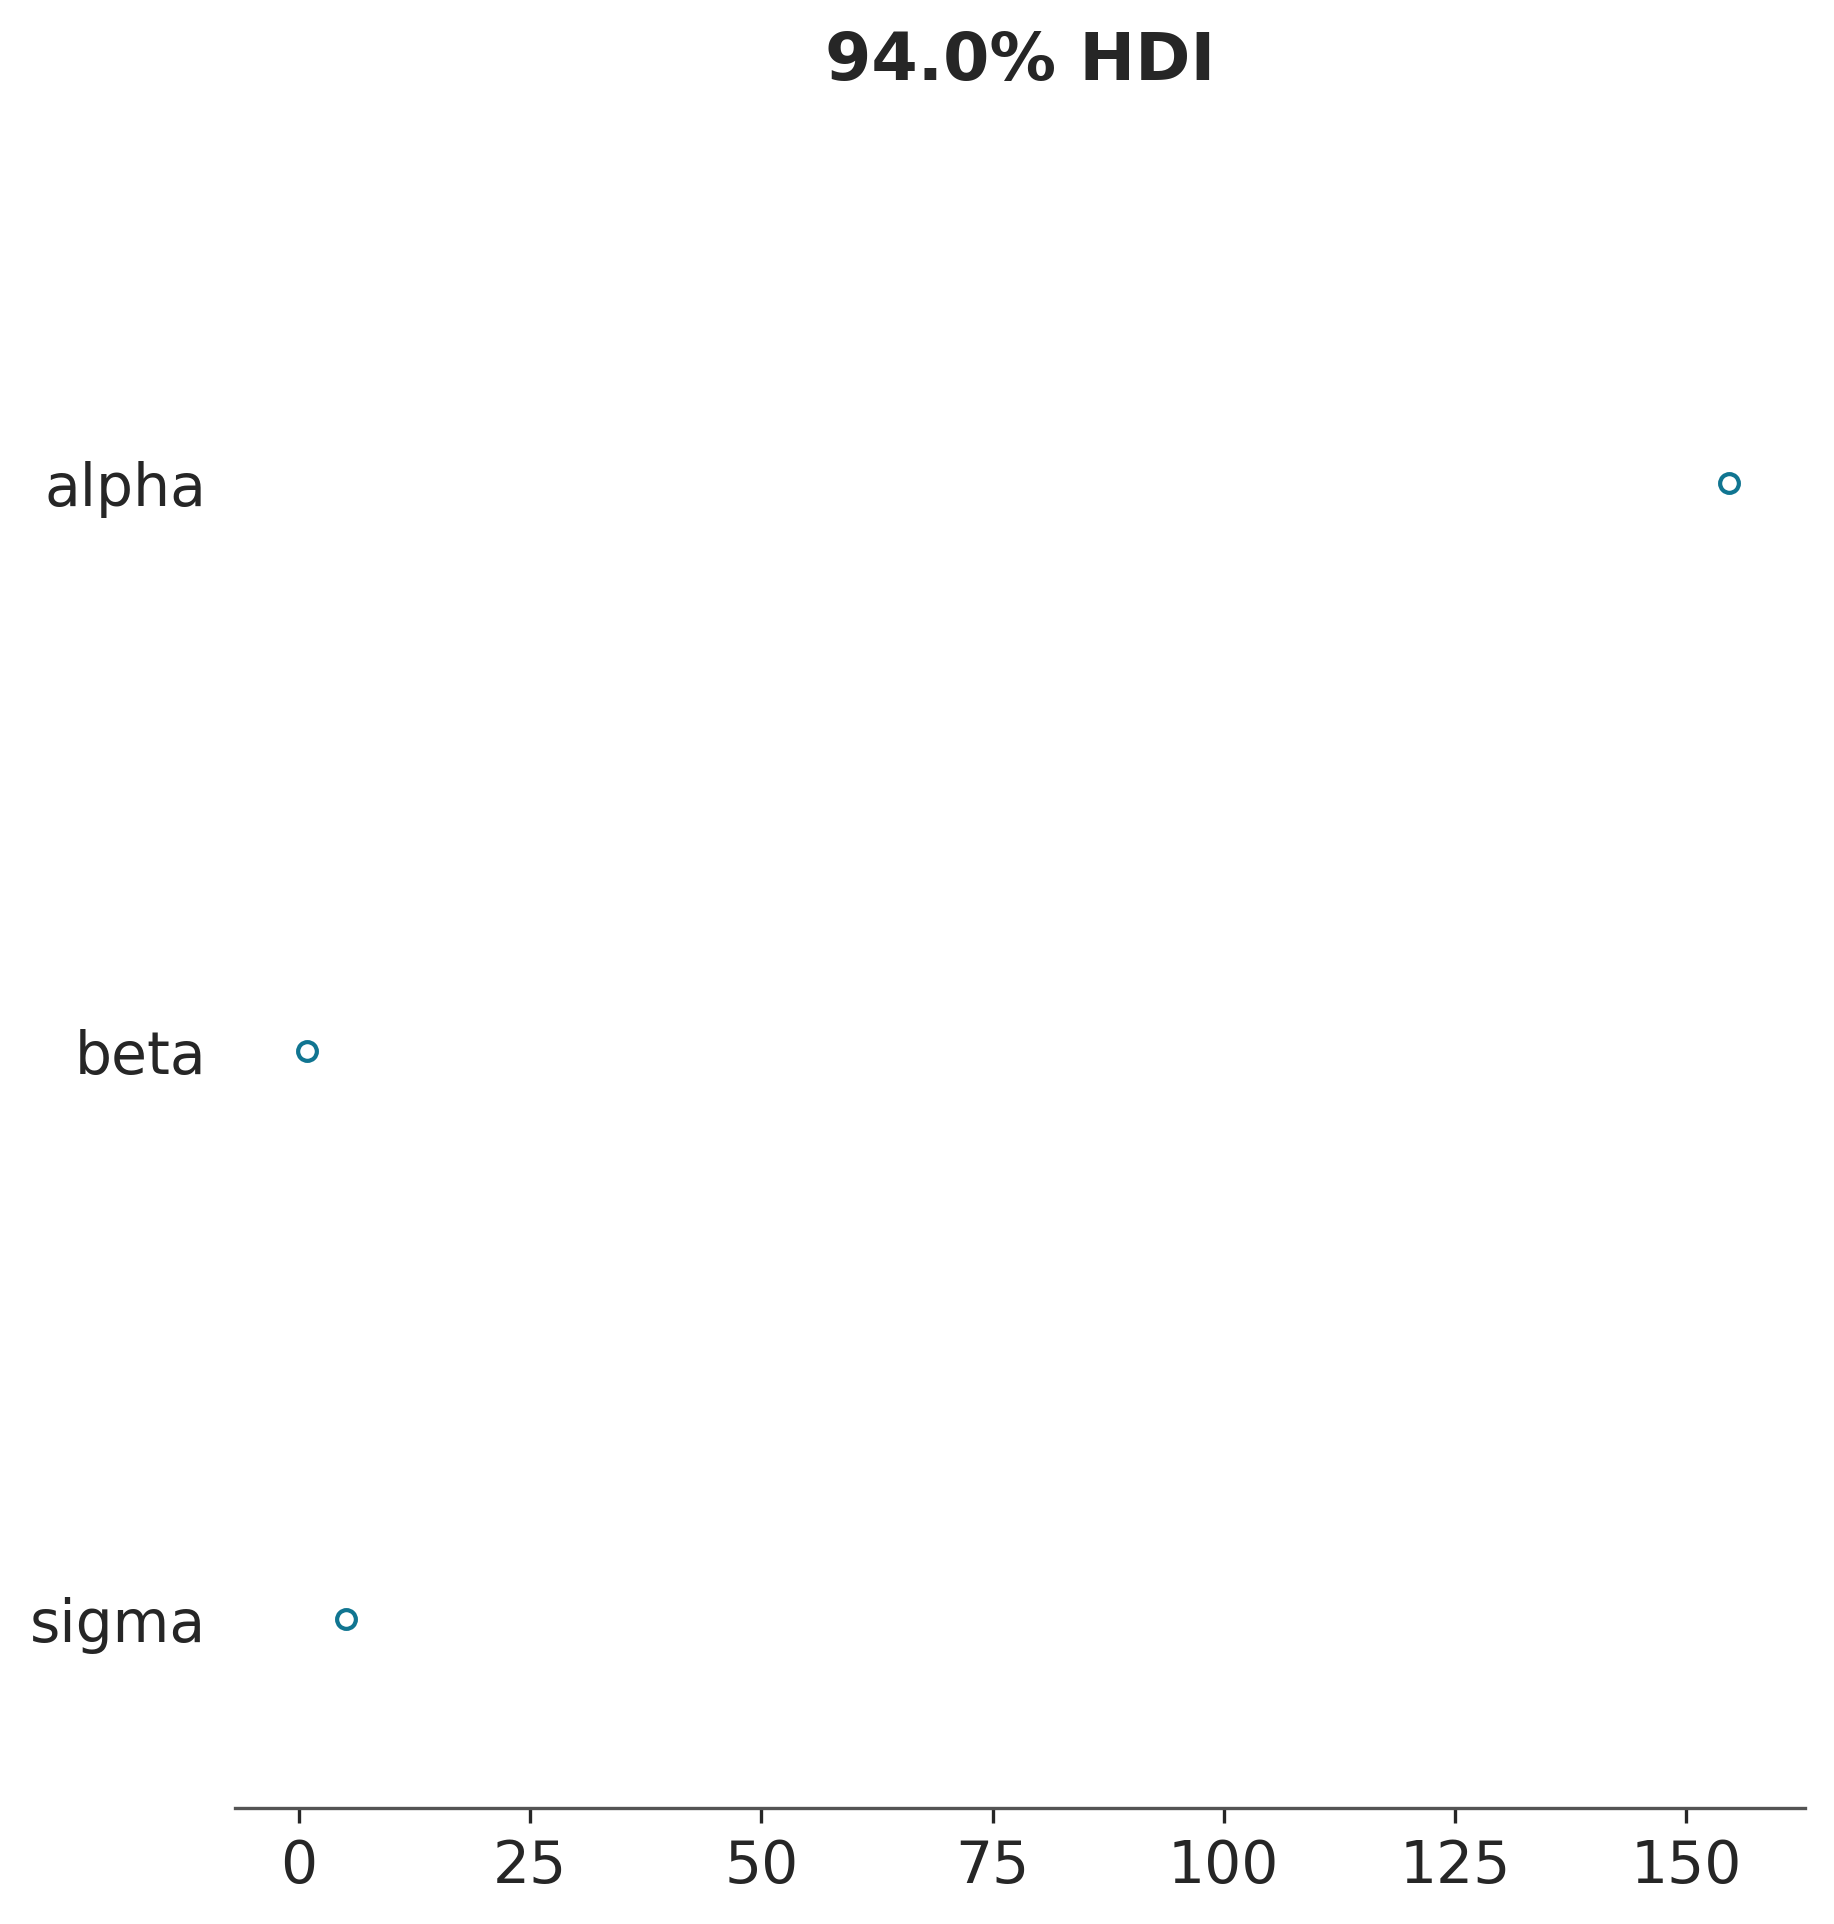

In [50]:
az.plot_forest(idata_over_18_heights, var_names=["alpha", "beta", "~mu"], combined=True)

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

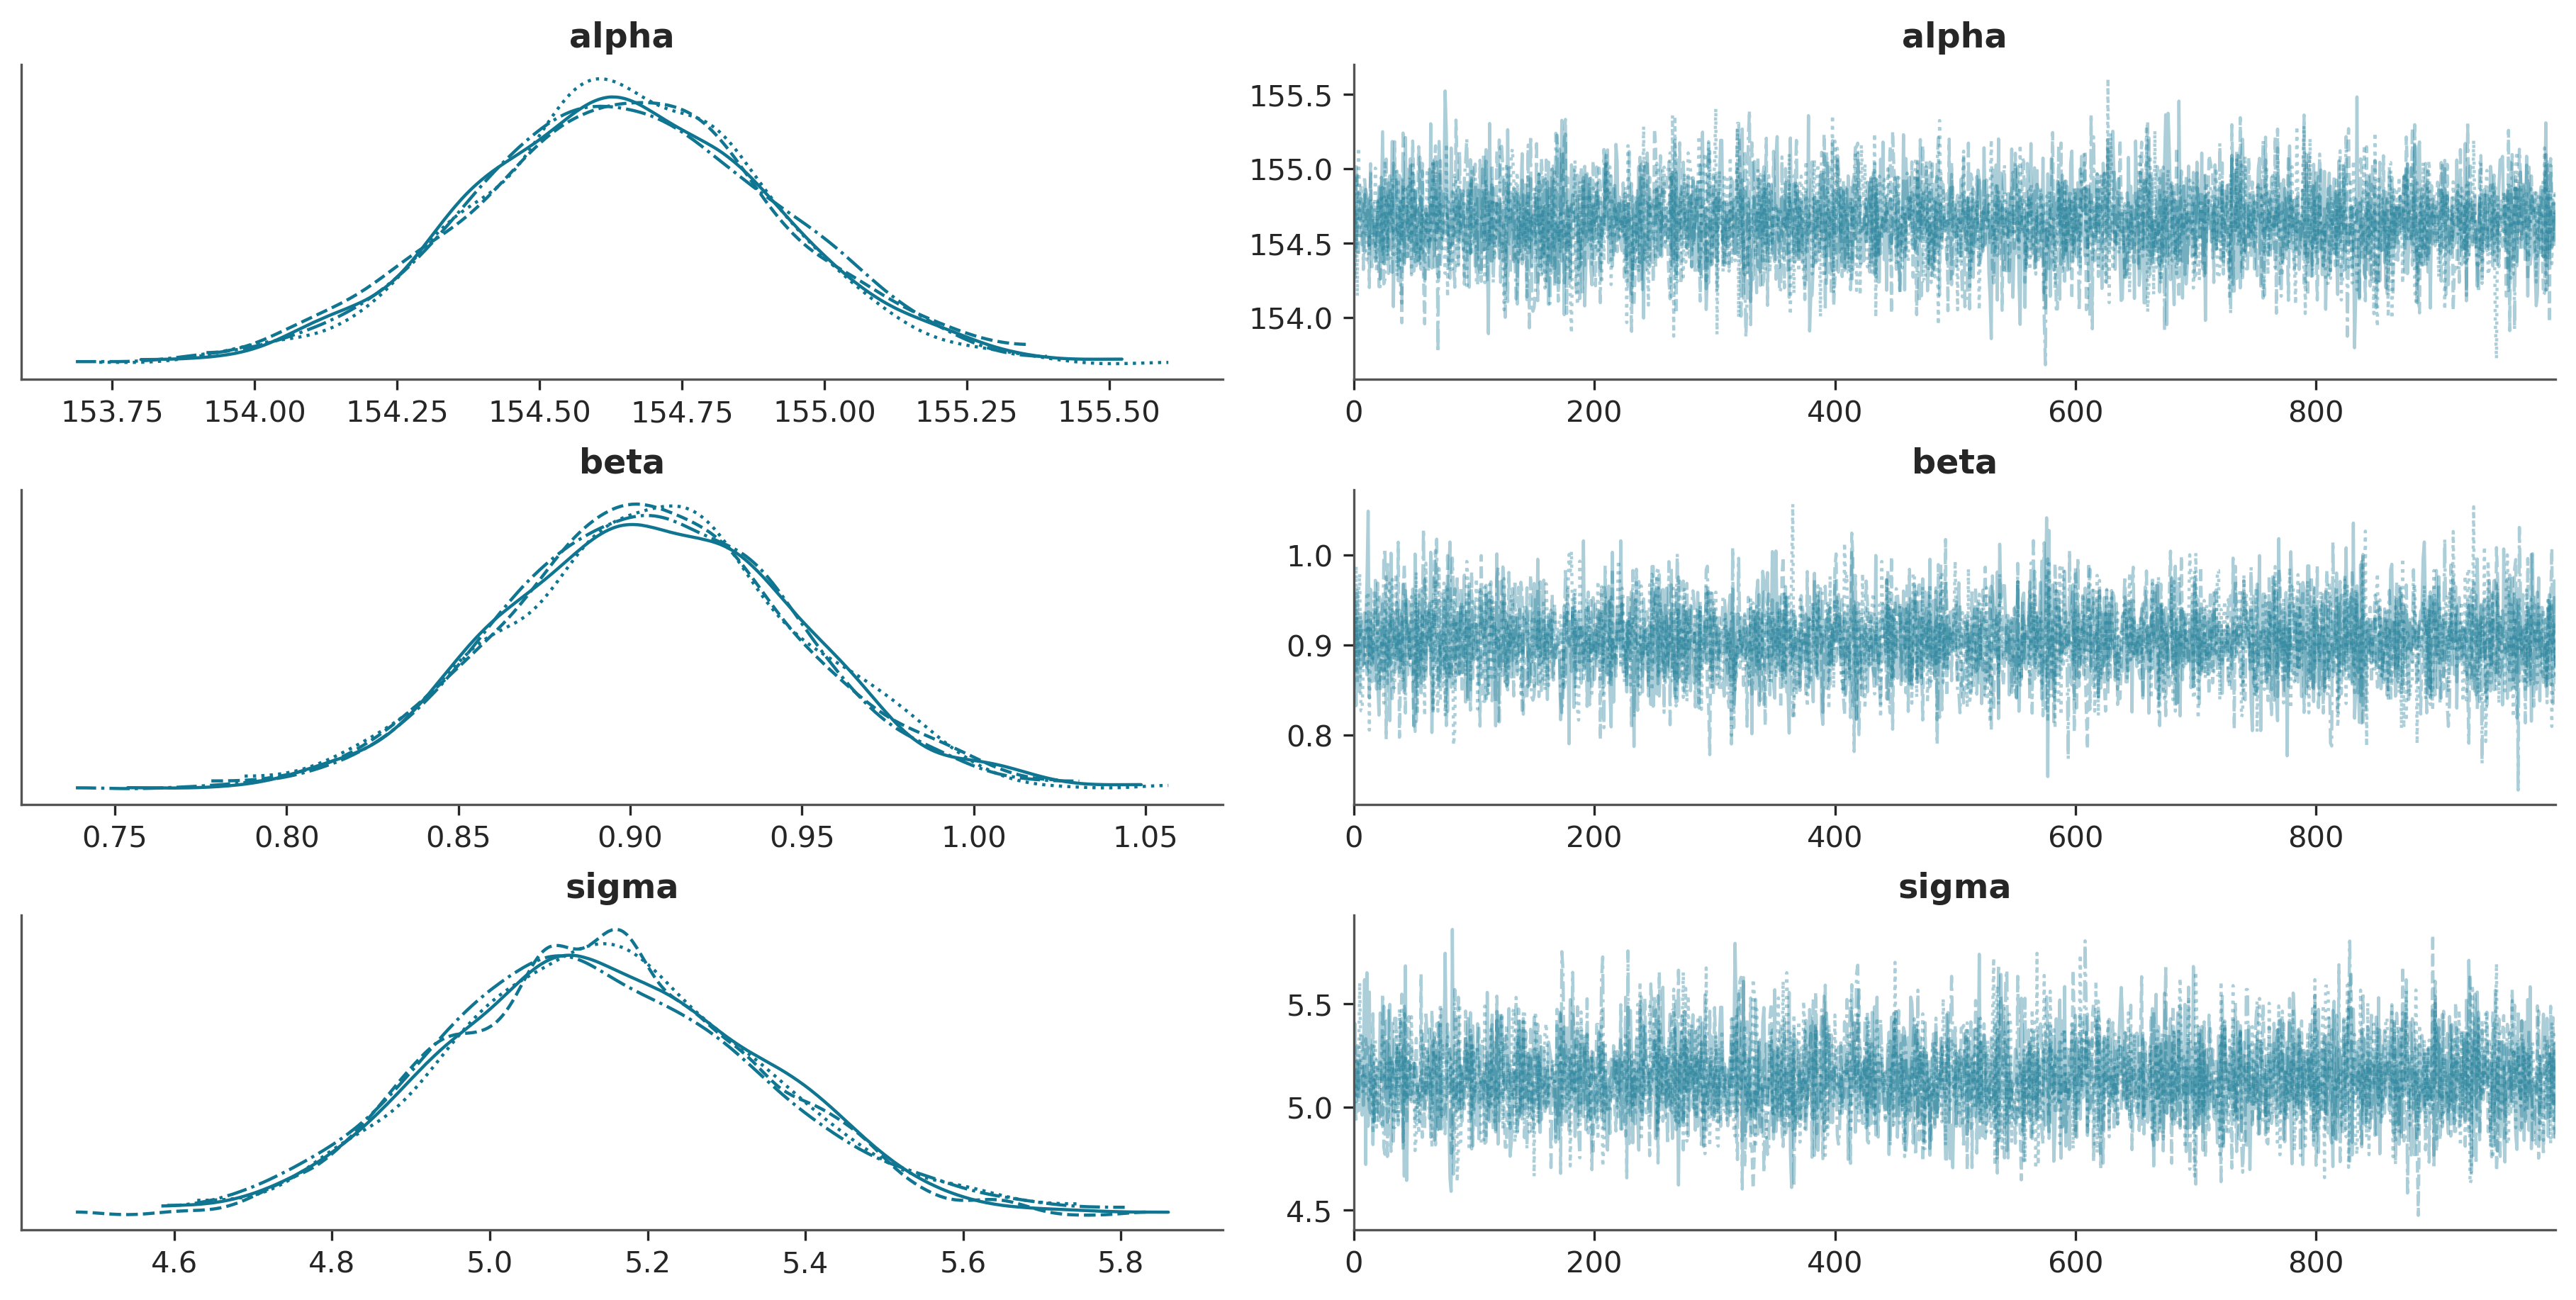

In [51]:
az.plot_trace(idata_over_18_heights, var_names=["~mu"])

In [52]:
az.extract(idata_over_18_heights, group='posterior_predictive')

<xarray.Dataset>
Dimensions:            (height_pred_dim_2: 346, sample: 4000)
Coordinates:
  * height_pred_dim_2  (height_pred_dim_2) int64 0 1 2 3 4 ... 342 343 344 345
  * sample             (sample) object MultiIndex
  * chain              (sample) int64 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
  * draw               (sample) int64 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
Data variables:
    height_pred        (height_pred_dim_2, sample) float64 165.2 159.1 ... 165.0
Attributes:
    created_at:                 2025-04-18T06:05:41.856126
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0

<xarray.Dataset>
Dimensions:   (sample: 4000, mu_dim_0: 346)
Coordinates:
  * mu_dim_0  (mu_dim_0) int64 0 1 2 3 4 5 6 7 ... 339 340 341 342 343 344 345
  * sample    (sample) object MultiIndex
  * chain     (sample) int64 0 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3 3 3
  * draw      (sample) int64 0 1 2 3 4 5 6 7 ... 992 993 994 995 996 997 998 999
Data variables:
    alpha     (sample) float64 154.8 154.7 154.5 154.6 ... 154.8 154.5 154.8
    beta      (sample) float64 0.9659 0.8916 0.8324 ... 0.91 0.9529 0.8609
    sigma     (sample) float64 5.11 5.405 5.026 5.219 ... 5.024 5.24 5.27 4.99
    mu        (mu_dim_0, sample) float64 157.5 157.2 156.8 ... 161.6 161.6 161.3
Attributes:
    created_at:                 2025-04-18T06:05:39.797650
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              2.0775771141052246
    tuning_steps:               1000

/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/plots/hdiplot.py:160: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/plots/hdiplot.py:160: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


Text(0.5, 0.01, 'Weight vs Height fit and posterior predictive checks')

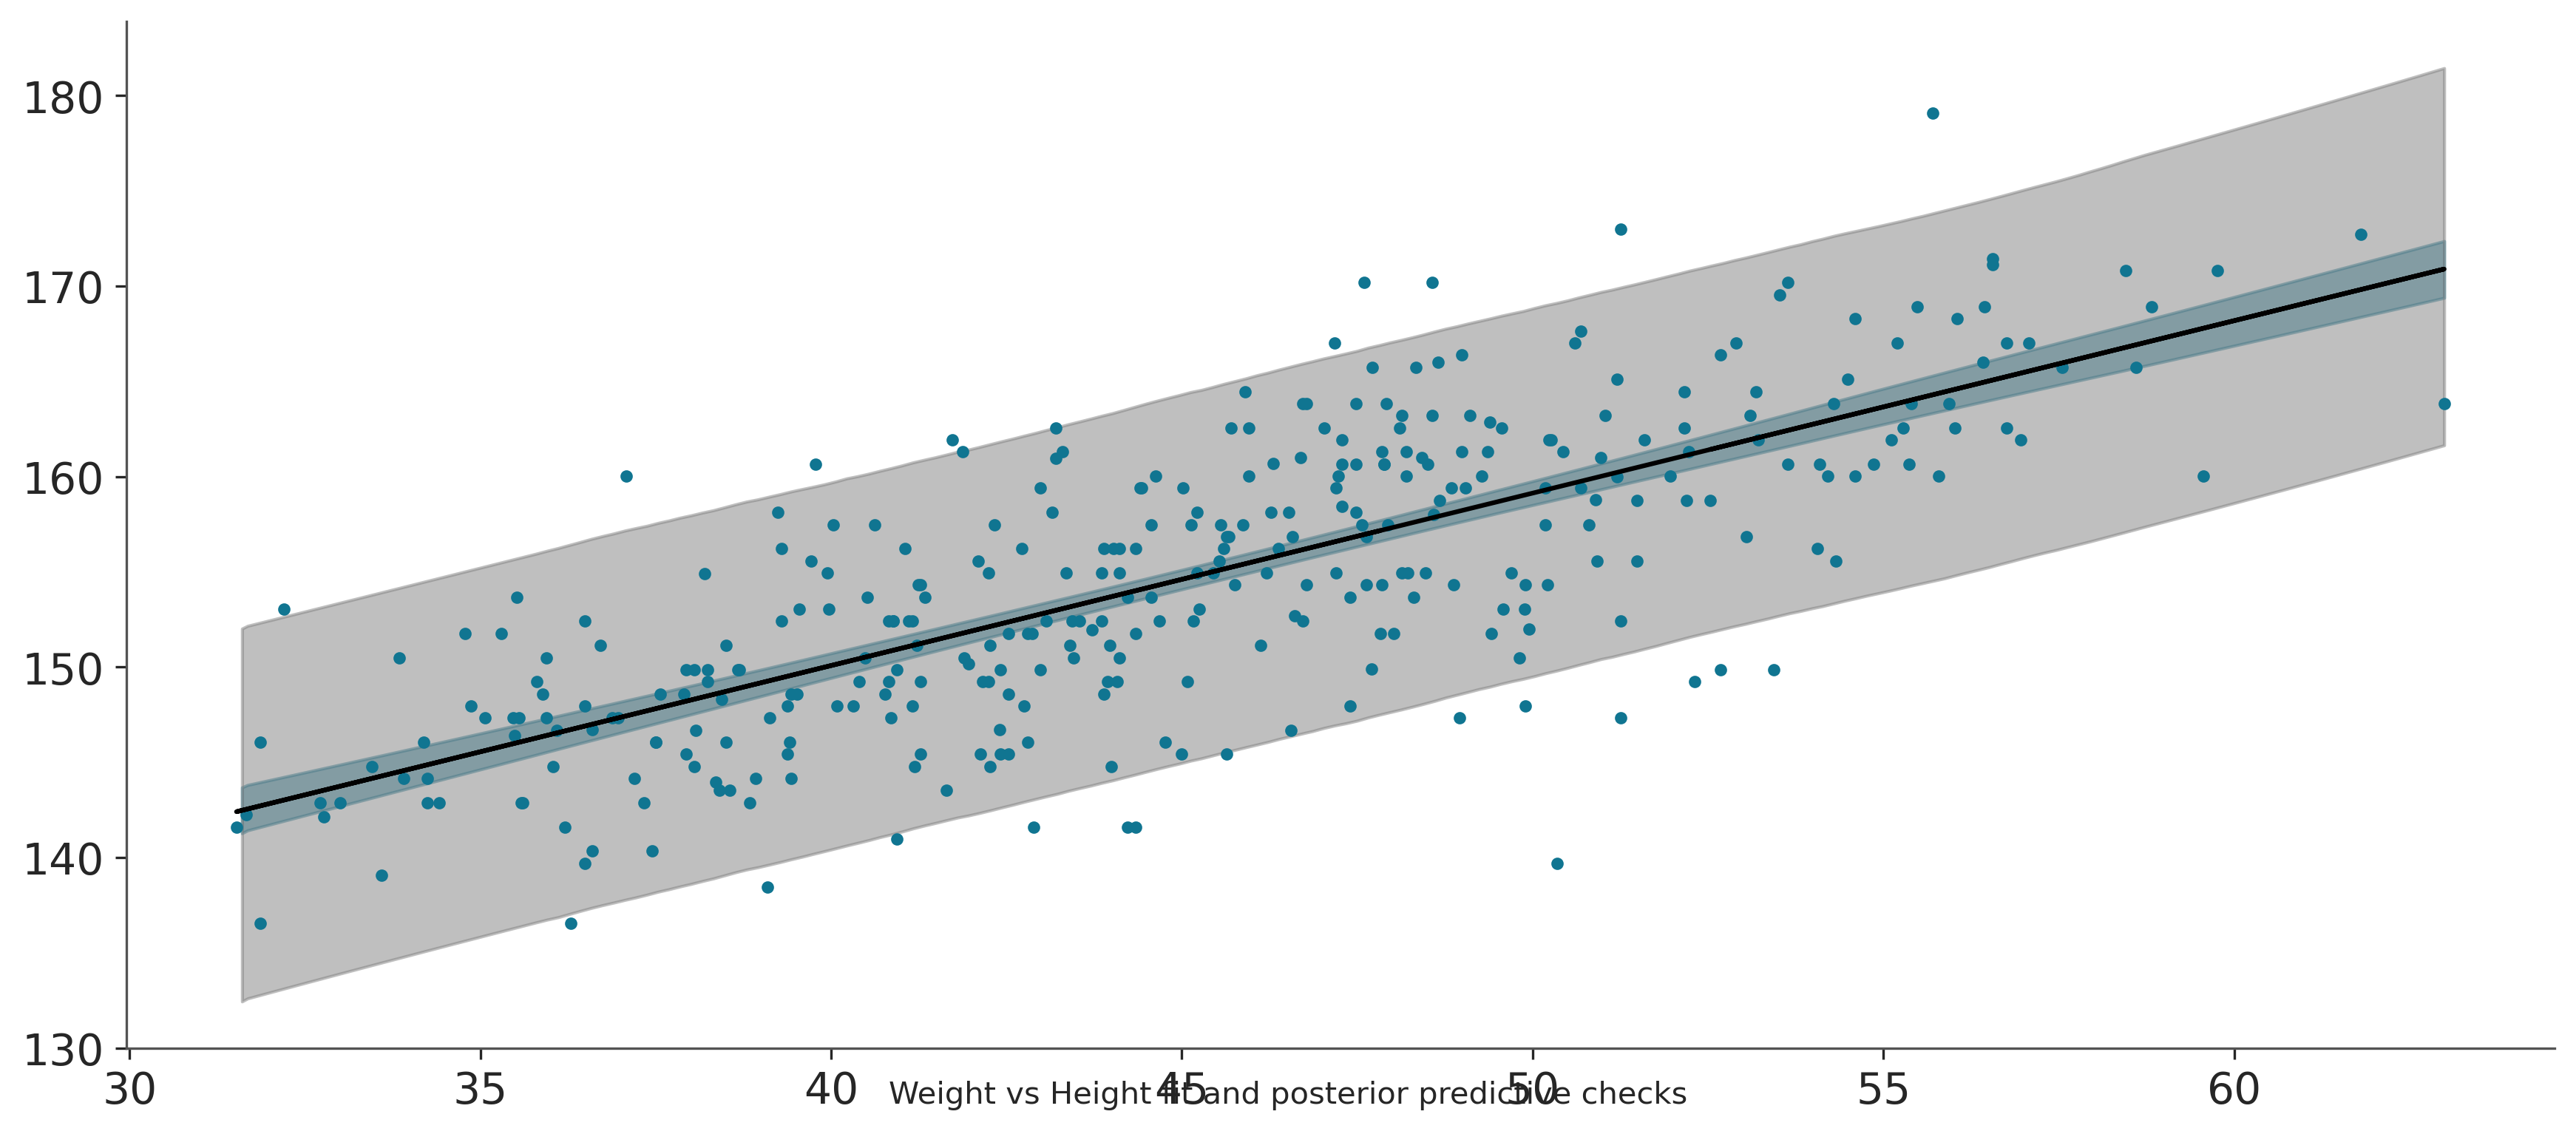

In [53]:
fig, ax = plt.subplots()

ax.plot(howell_over18.weight, howell_over18.height, "C0.")
posterior = az.extract(idata_over_18_heights, group='posterior')
display(posterior)
pps = az.extract(idata_over_18_heights, group='posterior_predictive')['height_pred']
mu_m = posterior['mu'].mean("sample")  # az.extract stacks chains/draws as sample
e_m = posterior['sigma'].mean("sample")

ax.plot(howell_over18.weight, mu_m, c="k")
az.plot_hdi(howell_over18.weight, posterior['mu'].T, color="C0")
az.plot_hdi(howell_over18.weight, pps.T, color="gray")

# Place title below the chart
fig.text(0.5, 0.01, "Weight vs Height fit and posterior predictive checks", 
         ha="center", va="bottom")

In [54]:
weights = (45.73, 65.8, 54.2, 32.59) - mean_weight_age18

In [55]:
with over_18_heights:
    pm.set_data({"weight_shared": weights})
    ppc = pm.sample_posterior_predictive(idata_over_18_heights, random_seed=123)
    y_ppc = ppc.posterior_predictive["height_pred"].stack(sample=("chain", "draw"))

Sampling: [height_pred]


In [56]:
ppc

Inference data with groups:
	> posterior_predictive
	> observed_data
	> constant_data

In [57]:
y_ppc

<xarray.DataArray 'height_pred' (height_pred_dim_2: 4, sample: 4000)>
array([[152.46626327, 160.259709  , 146.62978225, ..., 147.38980287,
        151.66785453, 160.32170739],
       [174.57831452, 175.53370076, 172.01091021, ..., 165.23064002,
        166.90910474, 176.54769466],
       [163.04747083, 159.31387843, 164.41348357, ..., 166.65847706,
        162.71815279, 158.70769904],
       [143.59530189, 146.57649796, 144.46143573, ..., 149.56952917,
        143.68347367, 150.94045823]])
Coordinates:
  * height_pred_dim_2  (height_pred_dim_2) int64 0 1 2 3
  * sample             (sample) object MultiIndex
  * chain              (sample) int64 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
  * draw               (sample) int64 0 1 2 3 4 5 6 ... 994 995 996 997 998 999

In [58]:
grid, pdf = az.stats.density_utils._kde_linear(y_ppc.values)

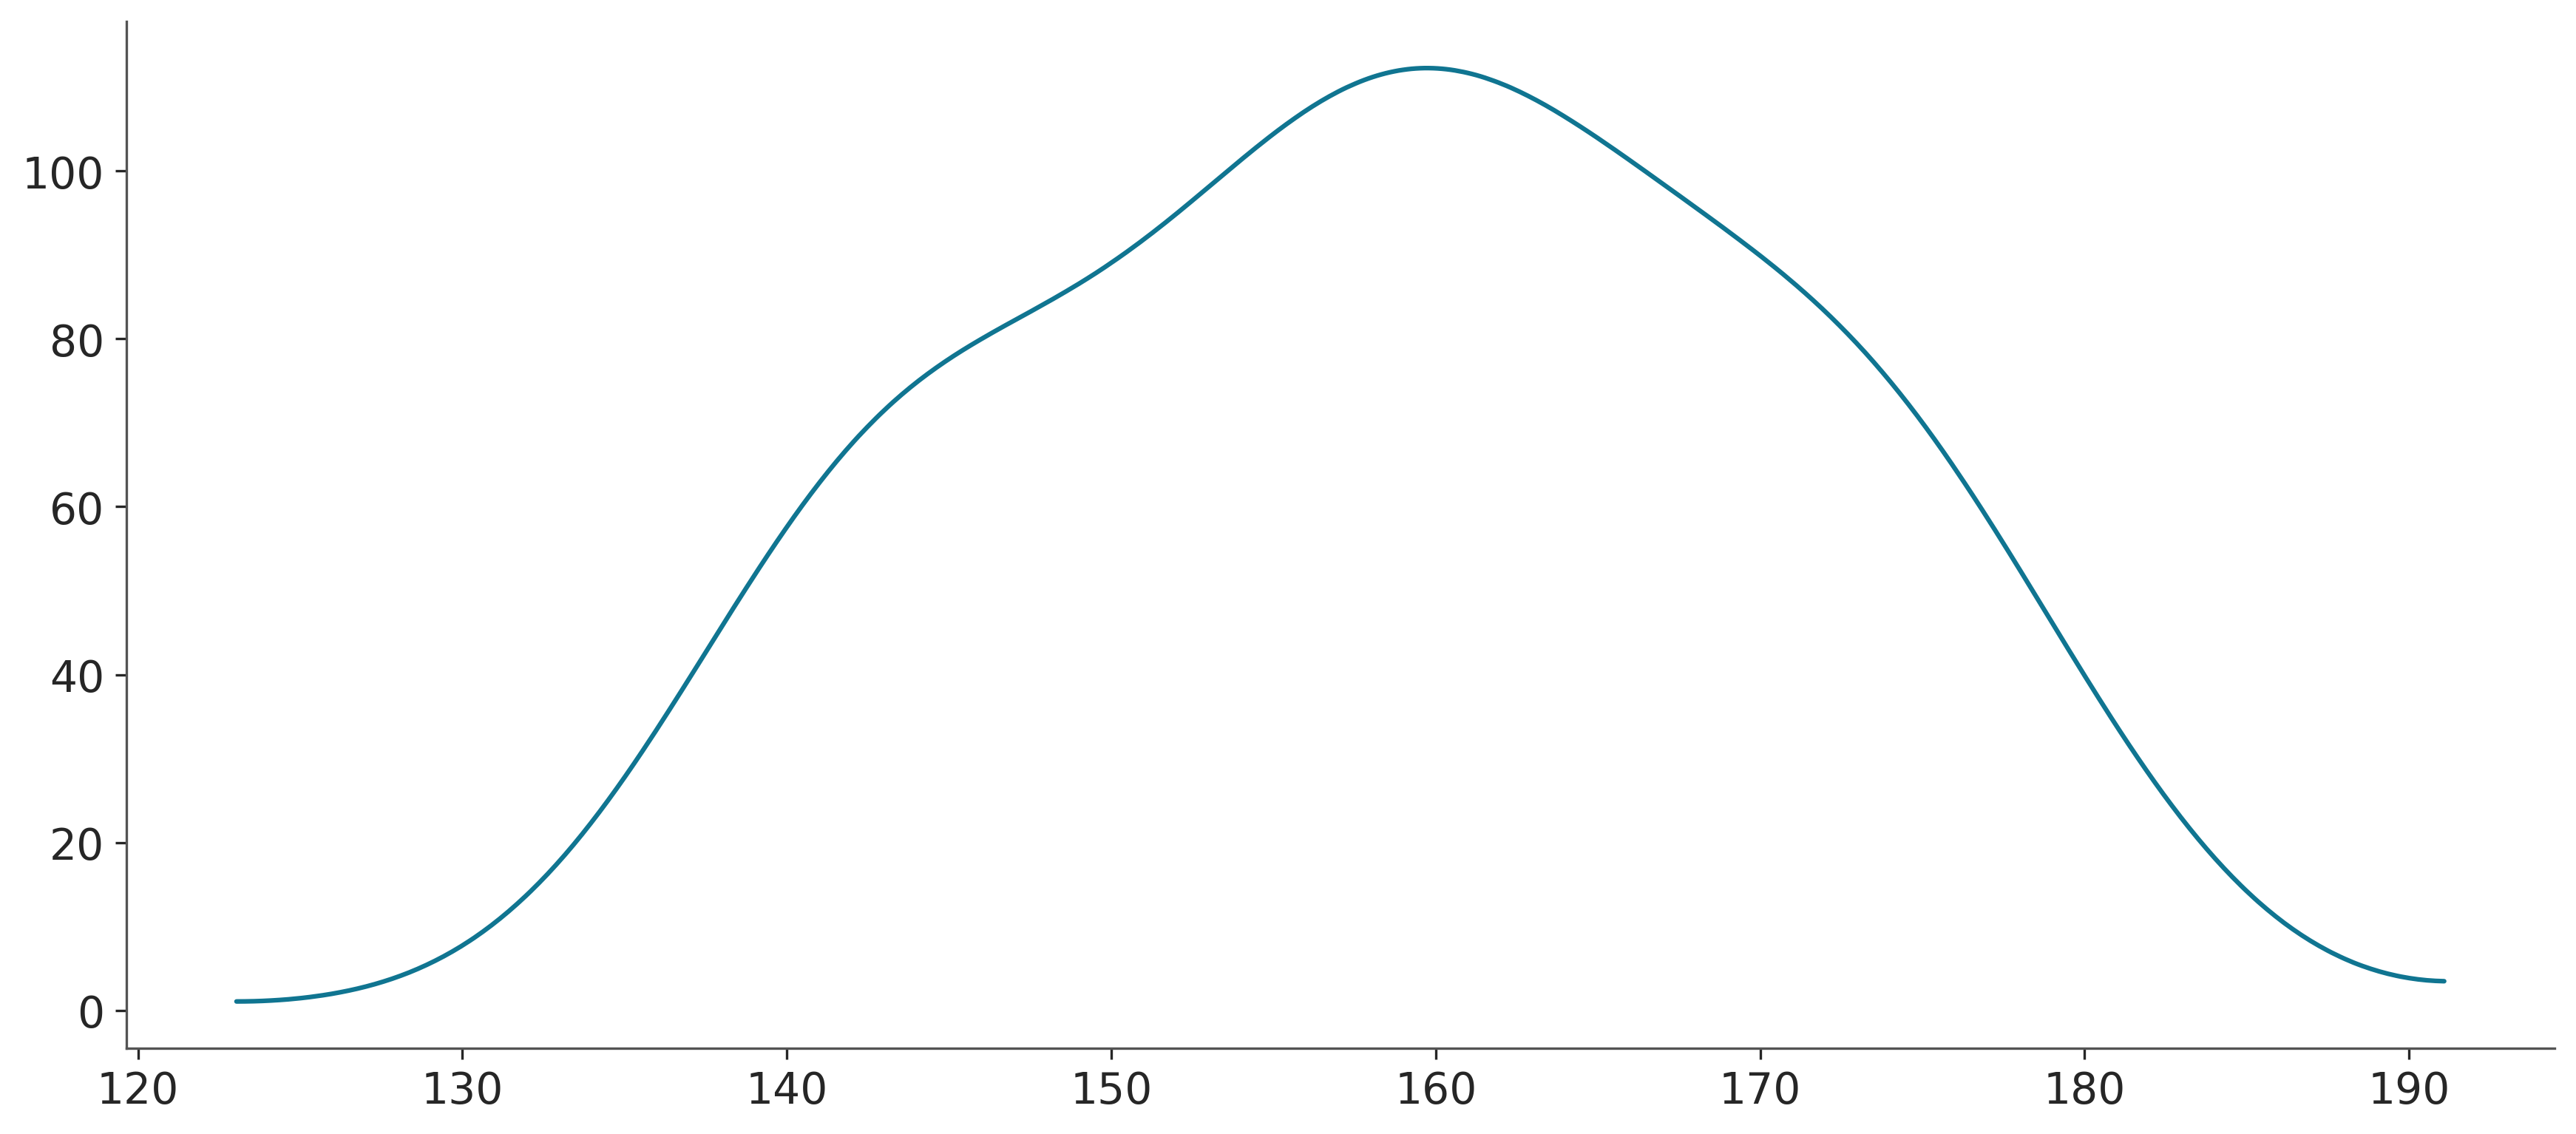

In [59]:
plt.plot(grid, pdf)

array([145.51599497, 164.35322746])

array([163.45400146, 183.18543789])

array([153.91706693, 173.00390695])

array([133.39677205, 152.68841992])

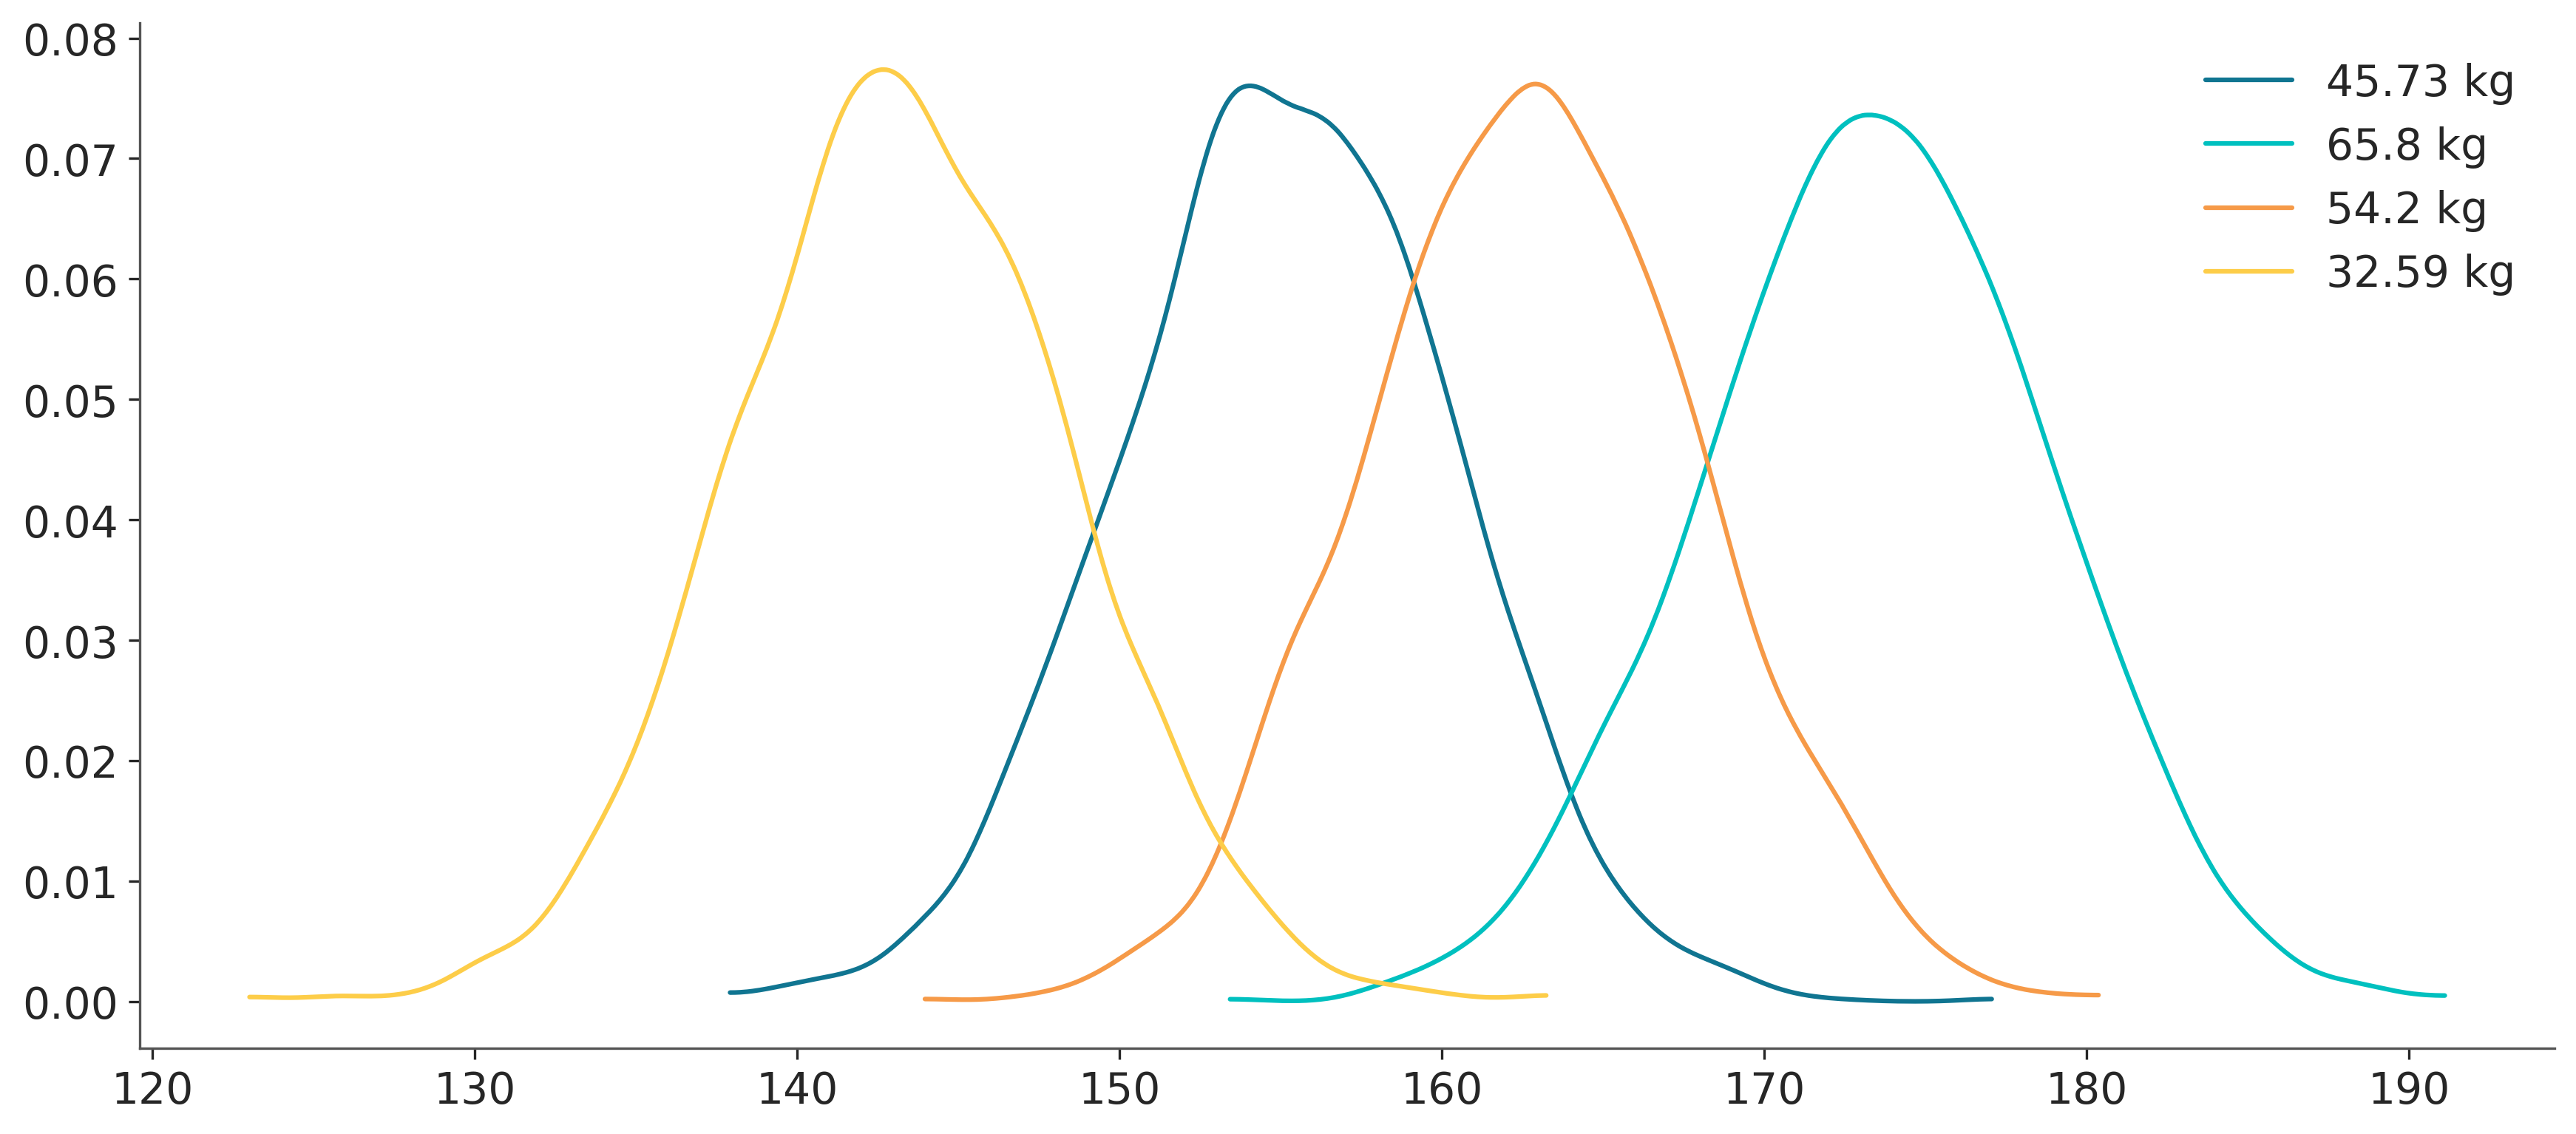

In [74]:
for idx, w in enumerate(weights):
    ppc_one = y_ppc.sel(height_pred_dim_2=idx).values
    ax = az.plot_kde(ppc_one, plot_kwargs={"color": f"C{idx}"}, label=f"{w + mean_weight_age18} kg")
    hdi_values = az.hdi(ppc_one)  # HDI 계산
    display(hdi_values)


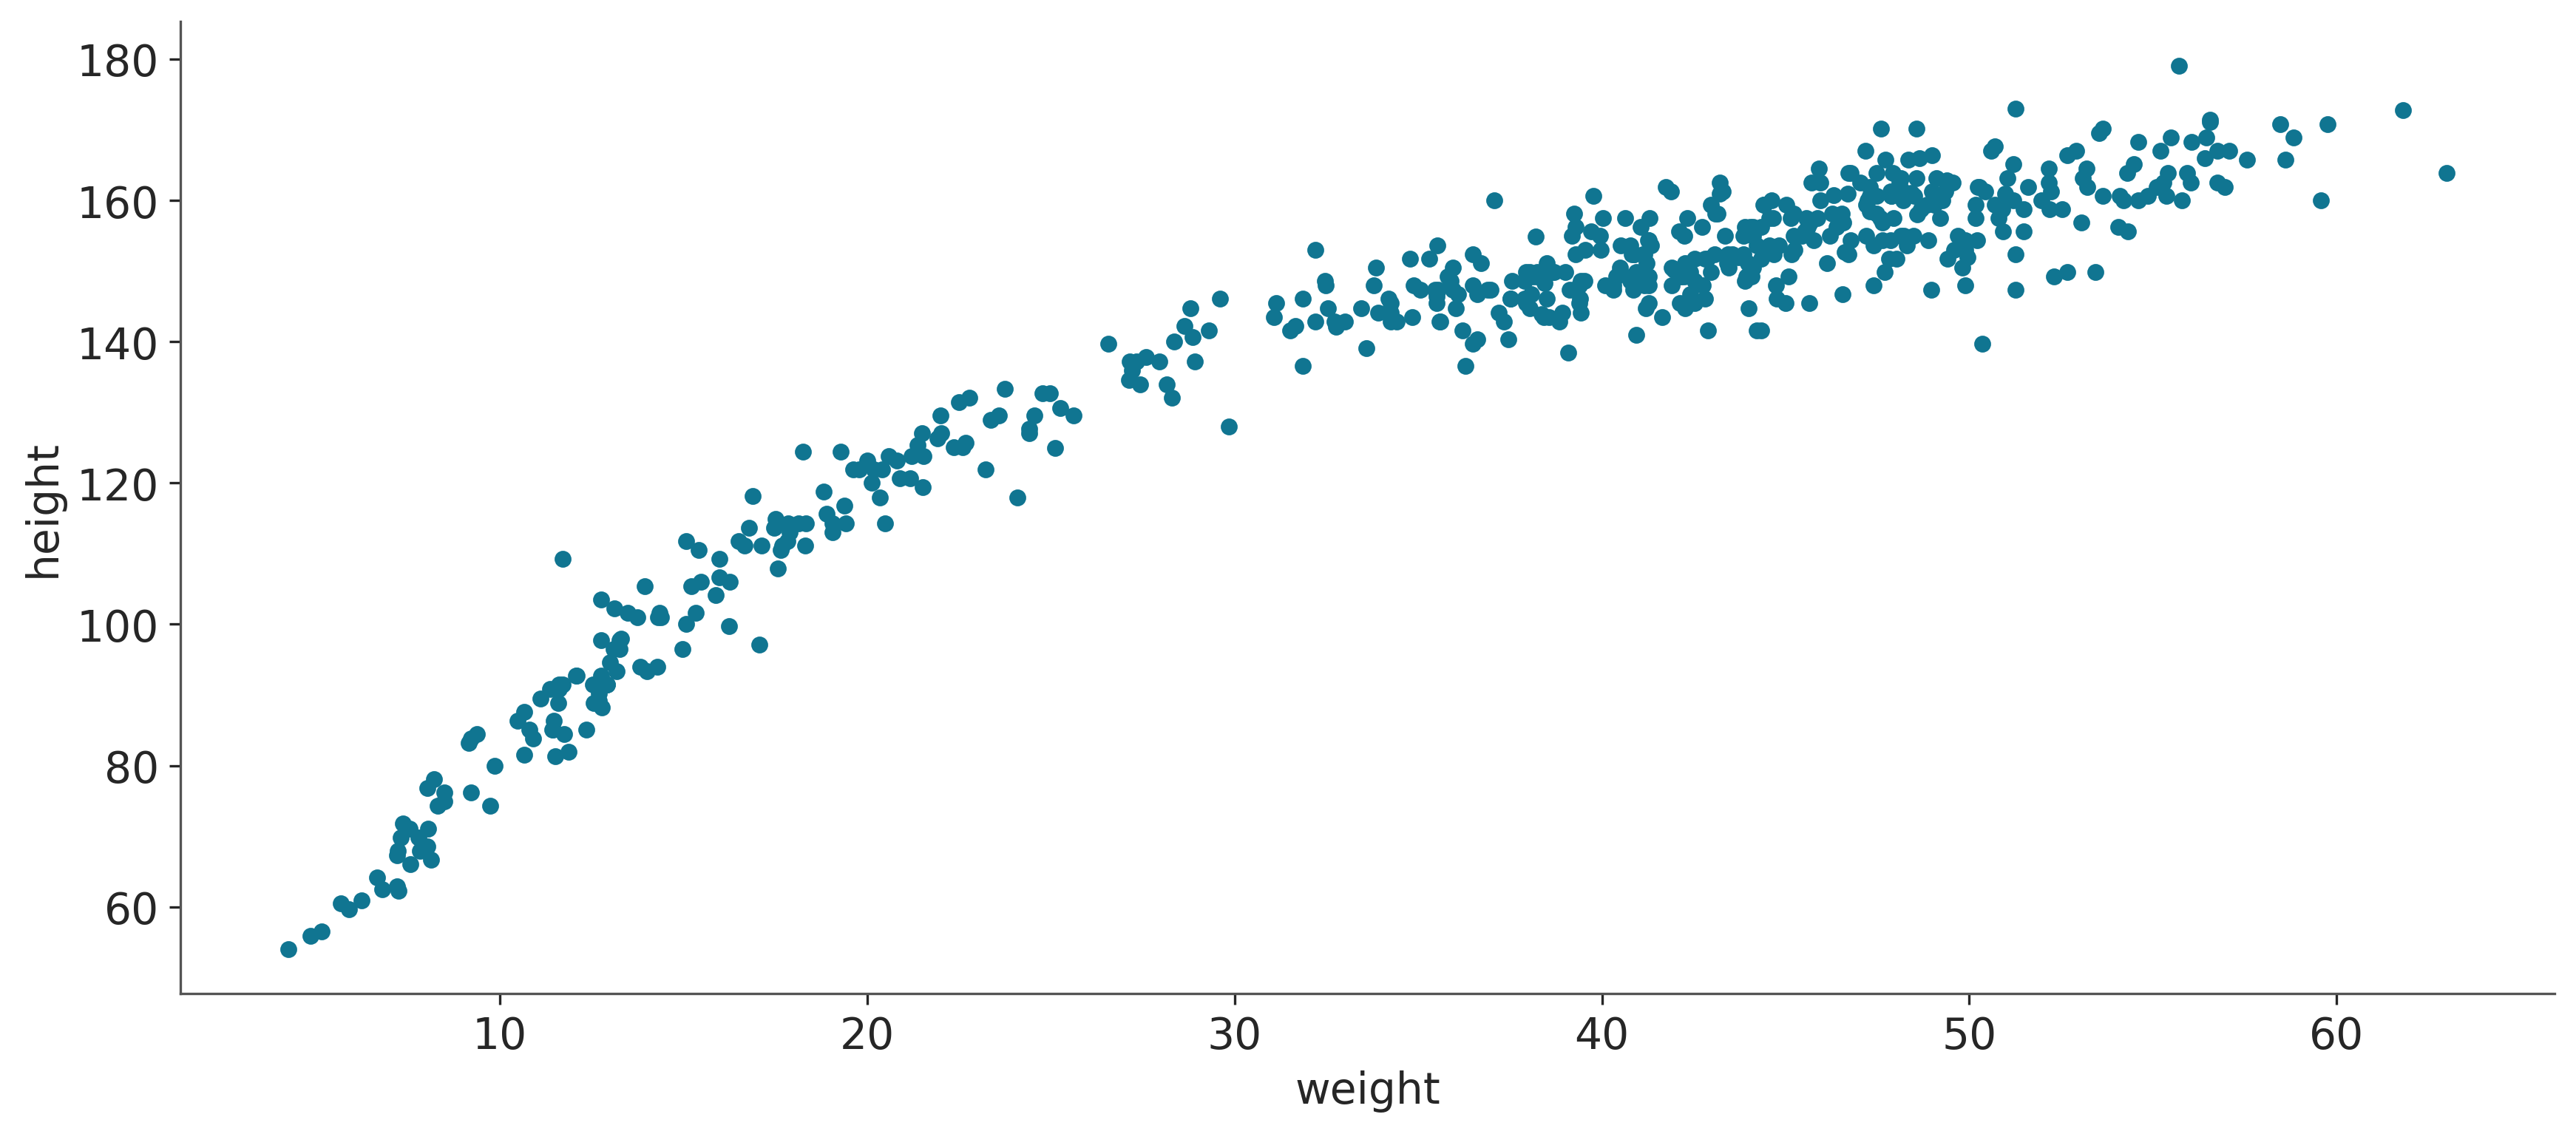

In [75]:
howell.plot(kind="scatter", x="weight", y="height");

In [76]:
mean_weight = howell.weight.mean()
mean_weight

35.610617592463235

In [77]:
howell['weight_centered'] = howell['weight'] - mean_weight
howell

,height,weight,age,male,weight_centered
0,151.765,47.825606,63.0,1,12.214989
1,139.700,36.485807,63.0,0,0.875189
2,136.525,31.864838,65.0,0,-3.745780
3,156.845,53.041914,41.0,1,17.431297
4,145.415,41.276872,51.0,0,5.666254
...,...,...,...,...,...
539,145.415,31.127751,17.0,1,-4.482867
540,162.560,52.163080,31.0,1,16.552462
541,156.210,54.062497,21.0,0,18.451879
542,71.120,8.051258,0.0,1,-27.559360


In [78]:
with pm.Model() as heights:
    weight_shared = pm.MutableData("weight_shared", howell.weight_centered)
    
    # prior 
    alpha = pm.Normal("alpha", mu=howell["height"].mean(), sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1) 
    sigma = pm.HalfNormal("sigma", 10)

    mu = pm.Deterministic("mu", alpha + beta * weight_shared)

    height_pred = pm.Normal("height_pred", mu=mu, sigma=sigma, 
                            observed=howell["height"],
                            shape=weight_shared.shape[0])

    idata_heights = pm.sample()
    idata_heights = pm.sample_posterior_predictive(idata_heights, 
                                                           extend_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Sampling: [height_pred]


In [79]:
idata_heights

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data
	> constant_data

In [80]:
az.summary(idata_heights, var_names=["alpha", "beta", "~mu"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,138.256,0.376,137.584,138.951,0.004,0.003,7642.0,3229.0,1.0
beta,1.763,0.027,1.710,1.812,0.000,0.000,6298.0,2585.0,1.0
sigma,9.378,0.286,8.871,9.947,0.003,0.002,7413.0,3194.0,1.0


<xarray.Dataset>
Dimensions:   (sample: 4000, mu_dim_0: 544)
Coordinates:
  * mu_dim_0  (mu_dim_0) int64 0 1 2 3 4 5 6 7 ... 537 538 539 540 541 542 543
  * sample    (sample) object MultiIndex
  * chain     (sample) int64 0 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3 3 3
  * draw      (sample) int64 0 1 2 3 4 5 6 7 ... 992 993 994 995 996 997 998 999
Data variables:
    alpha     (sample) float64 137.6 138.0 138.3 138.3 ... 138.6 138.6 137.8
    beta      (sample) float64 1.772 1.77 1.729 1.764 ... 1.747 1.755 1.753
    sigma     (sample) float64 9.447 9.41 9.953 8.76 ... 9.573 9.158 9.208 9.807
    mu        (mu_dim_0, sample) float64 159.3 159.6 159.4 ... 168.2 168.3 167.5
Attributes:
    created_at:                 2025-04-18T07:57:25.751176
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              2.2218003273010254
    tuning_steps:               1000

/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/plots/hdiplot.py:160: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/plots/hdiplot.py:160: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


Text(0.5, -0.08, '$\\bf{Fig\\ 4.2}$: Weight vs Height fit and posterior predictive checks')

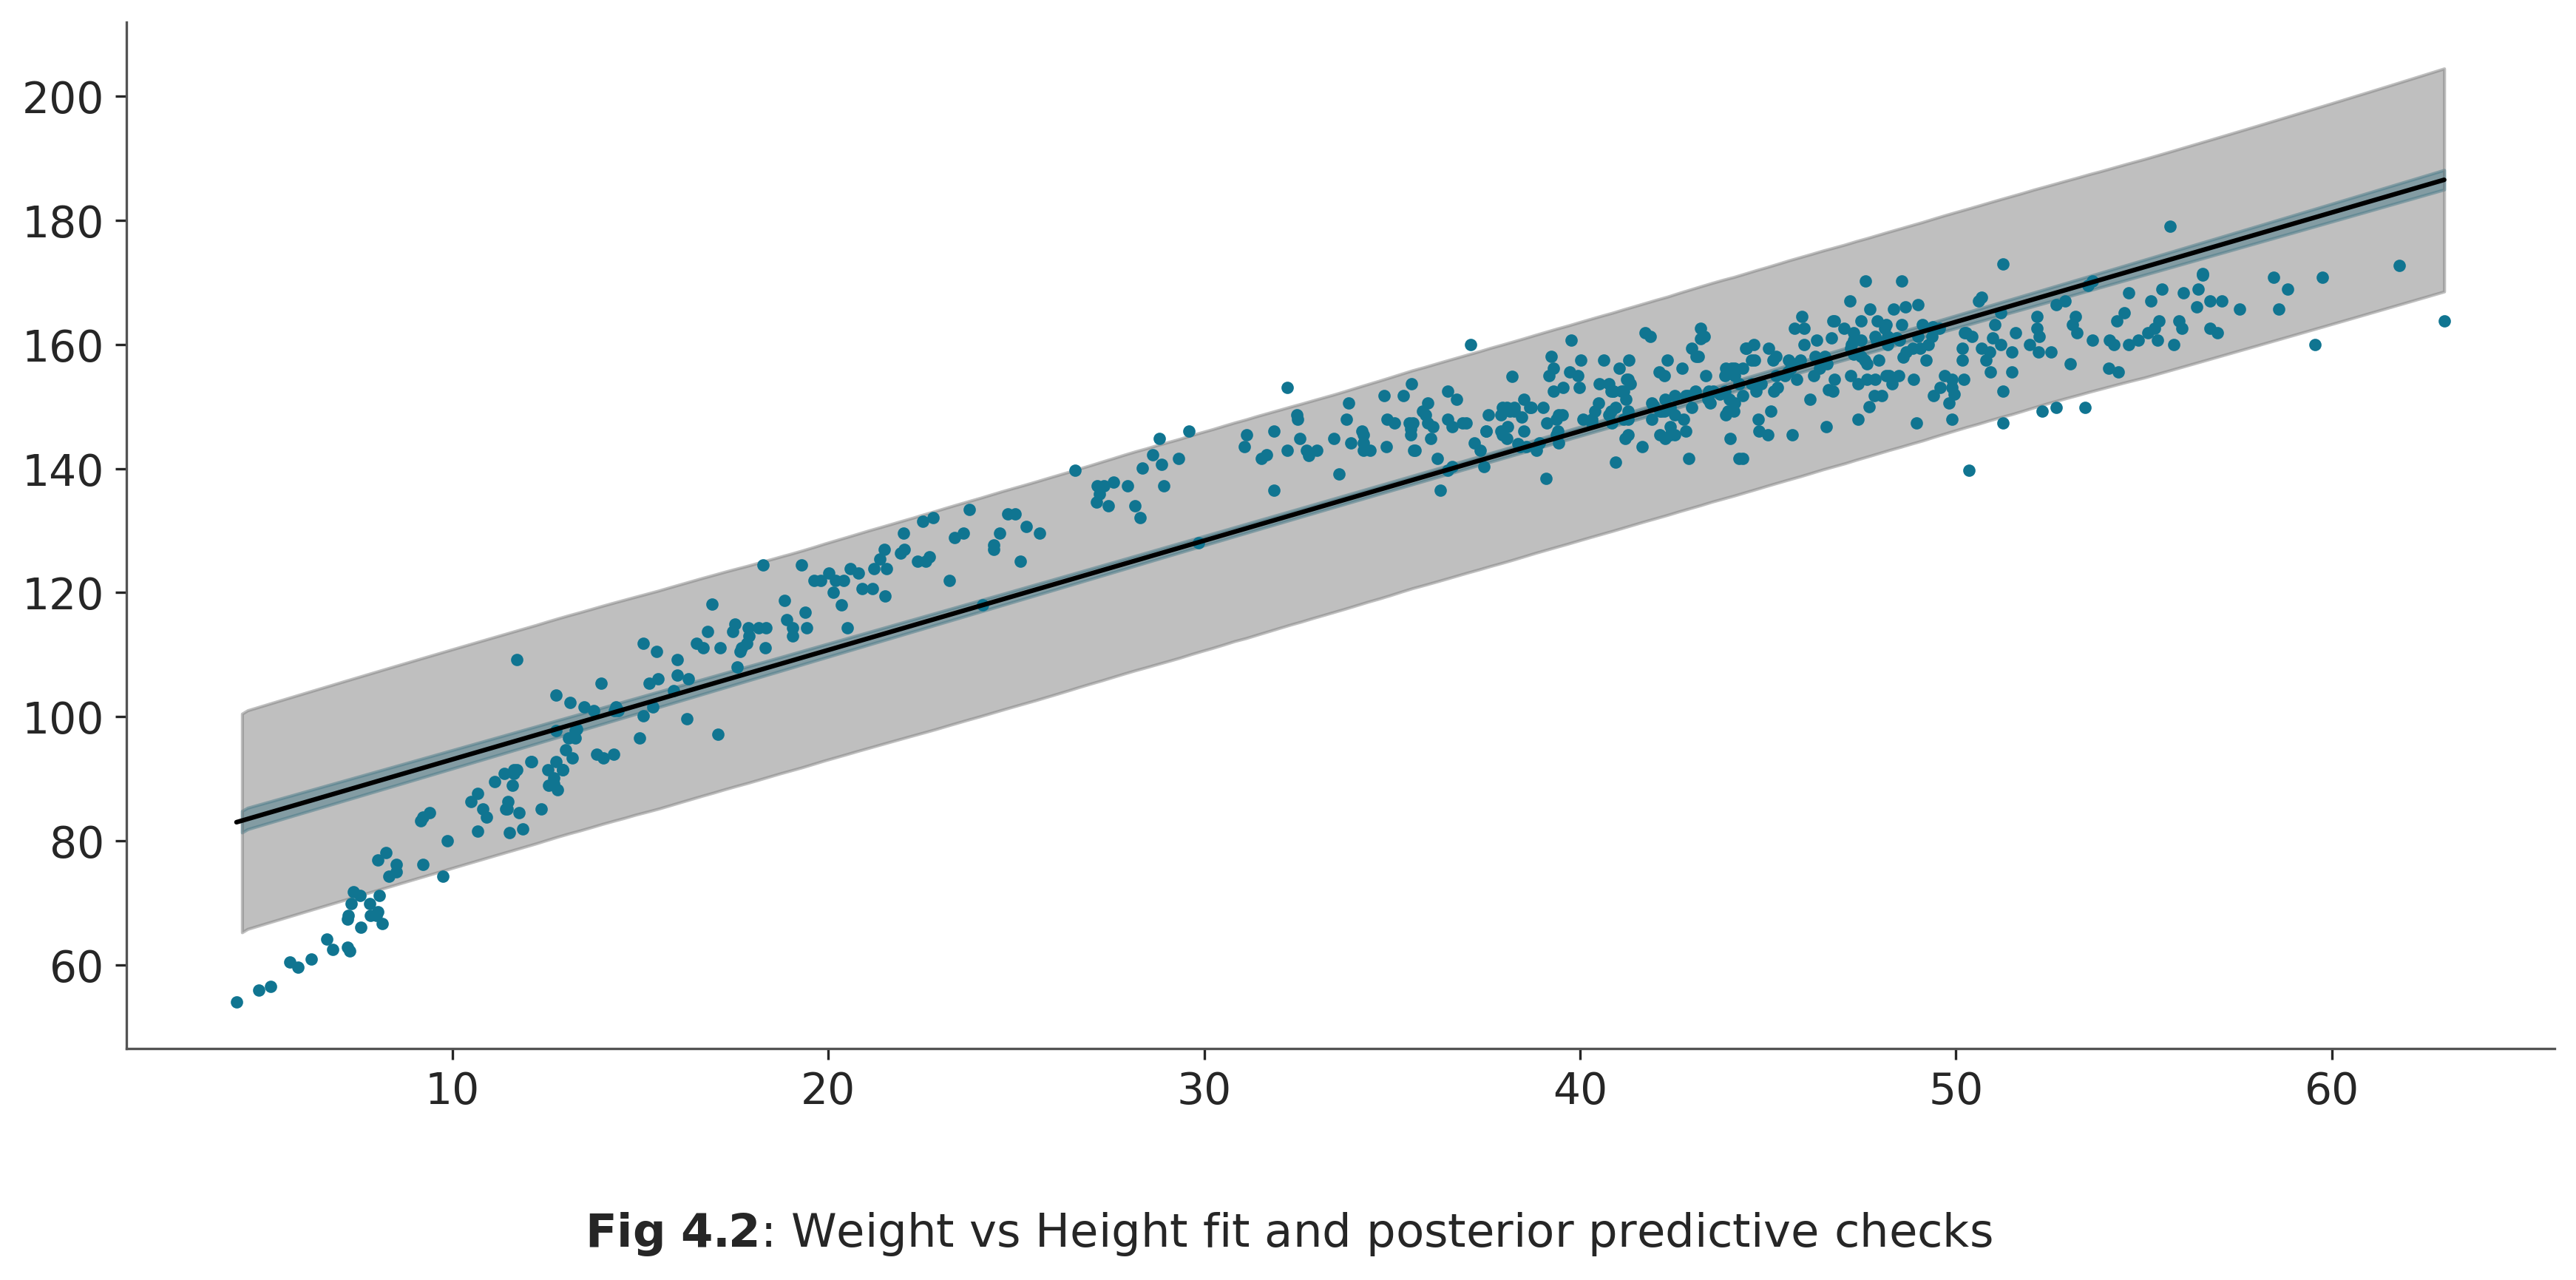

In [97]:
fig, ax = plt.subplots()

ax.plot(howell.weight, howell.height, "C0.")
posterior = az.extract(idata_heights, group='posterior')
display(posterior)
pps = az.extract(idata_heights, group='posterior_predictive')['height_pred']
mu_m = posterior['mu'].mean("sample")  # az.extract stacks chains/draws as sample
e_m = posterior['sigma'].mean("sample")

# ax.plot(howell.weight, mu_m, c="k")
az.plot_hdi(howell.weight, posterior['mu'].T, color="C0")
az.plot_hdi(howell.weight, pps.T, color="gray")

order = np.argsort(howell["weight"].values)
ax.plot(howell["weight"][order], mu_m[order], c="k")

# 하단 제목 추가 (Fig 번호는 bold, 나머지는 보통체)
fig.text(
    0.5, -0.08,
    r'$\bf{Fig\ 4.2}$: Weight vs Height fit and posterior predictive checks',
    ha='center',
    va='top',
    fontsize=15
)

In [111]:
with pm.Model() as heights:
    weight_shared = pm.MutableData("weight_shared", howell.weight)

    alpha = pm.Normal("alpha", 0, sigma=20)
    beta = pm.Normal("beta", sigma=10)

    gamma = pm.HalfNormal("gamma", sigma=10)
    delta = pm.HalfNormal("delta", sigma=10)

    mu = pm.Deterministic("mu", alpha + beta * pm.math.log(weight_shared))
    sigma = pm.Deterministic("sigma", gamma + delta * weight_shared)

    height_pred = pm.Normal("height_pred", 
                            mu=mu, sigma=sigma, 
                            observed=howell.height, 
                            shape=weight_shared.shape[0])
    idata_heights = pm.sample() 
    idata_heights = pm.sample_posterior_predictive(idata_heights, extend_inferencedata=True)
    

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma, delta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.
Sampling: [height_pred]


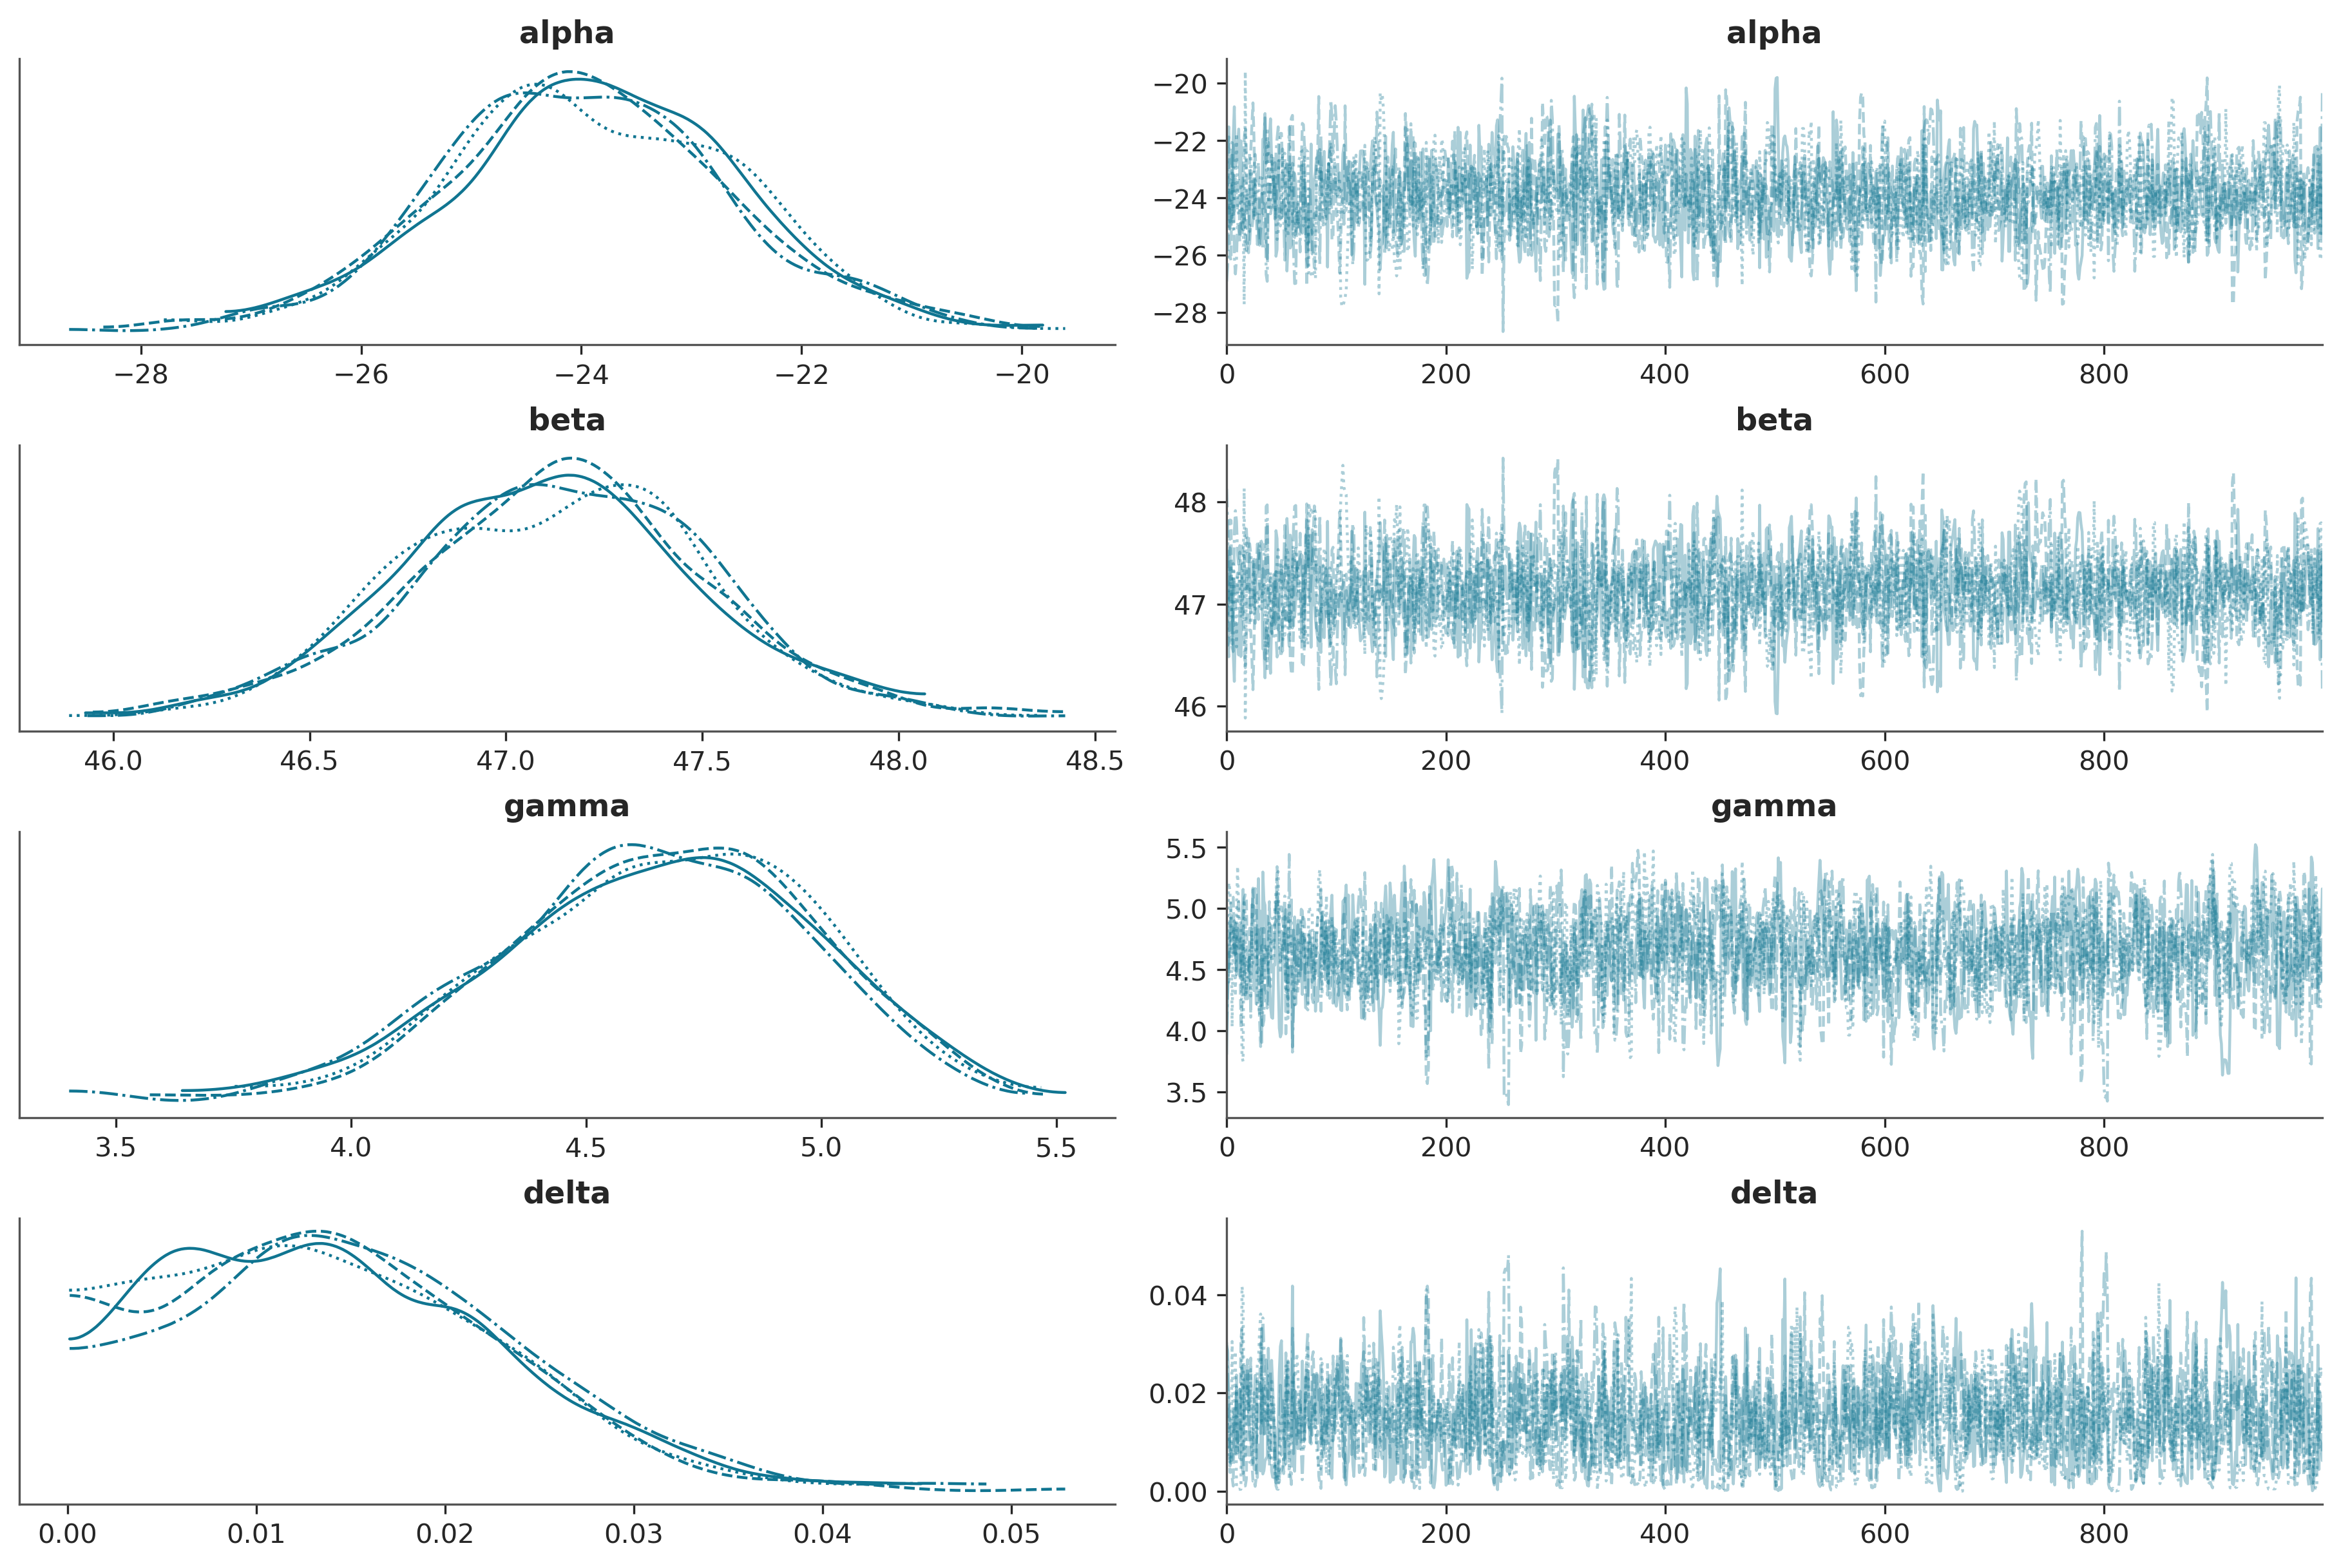

In [112]:
az.plot_trace(idata_heights, var_names=["~mu", "~sigma"]);

/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/plots/hdiplot.py:160: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


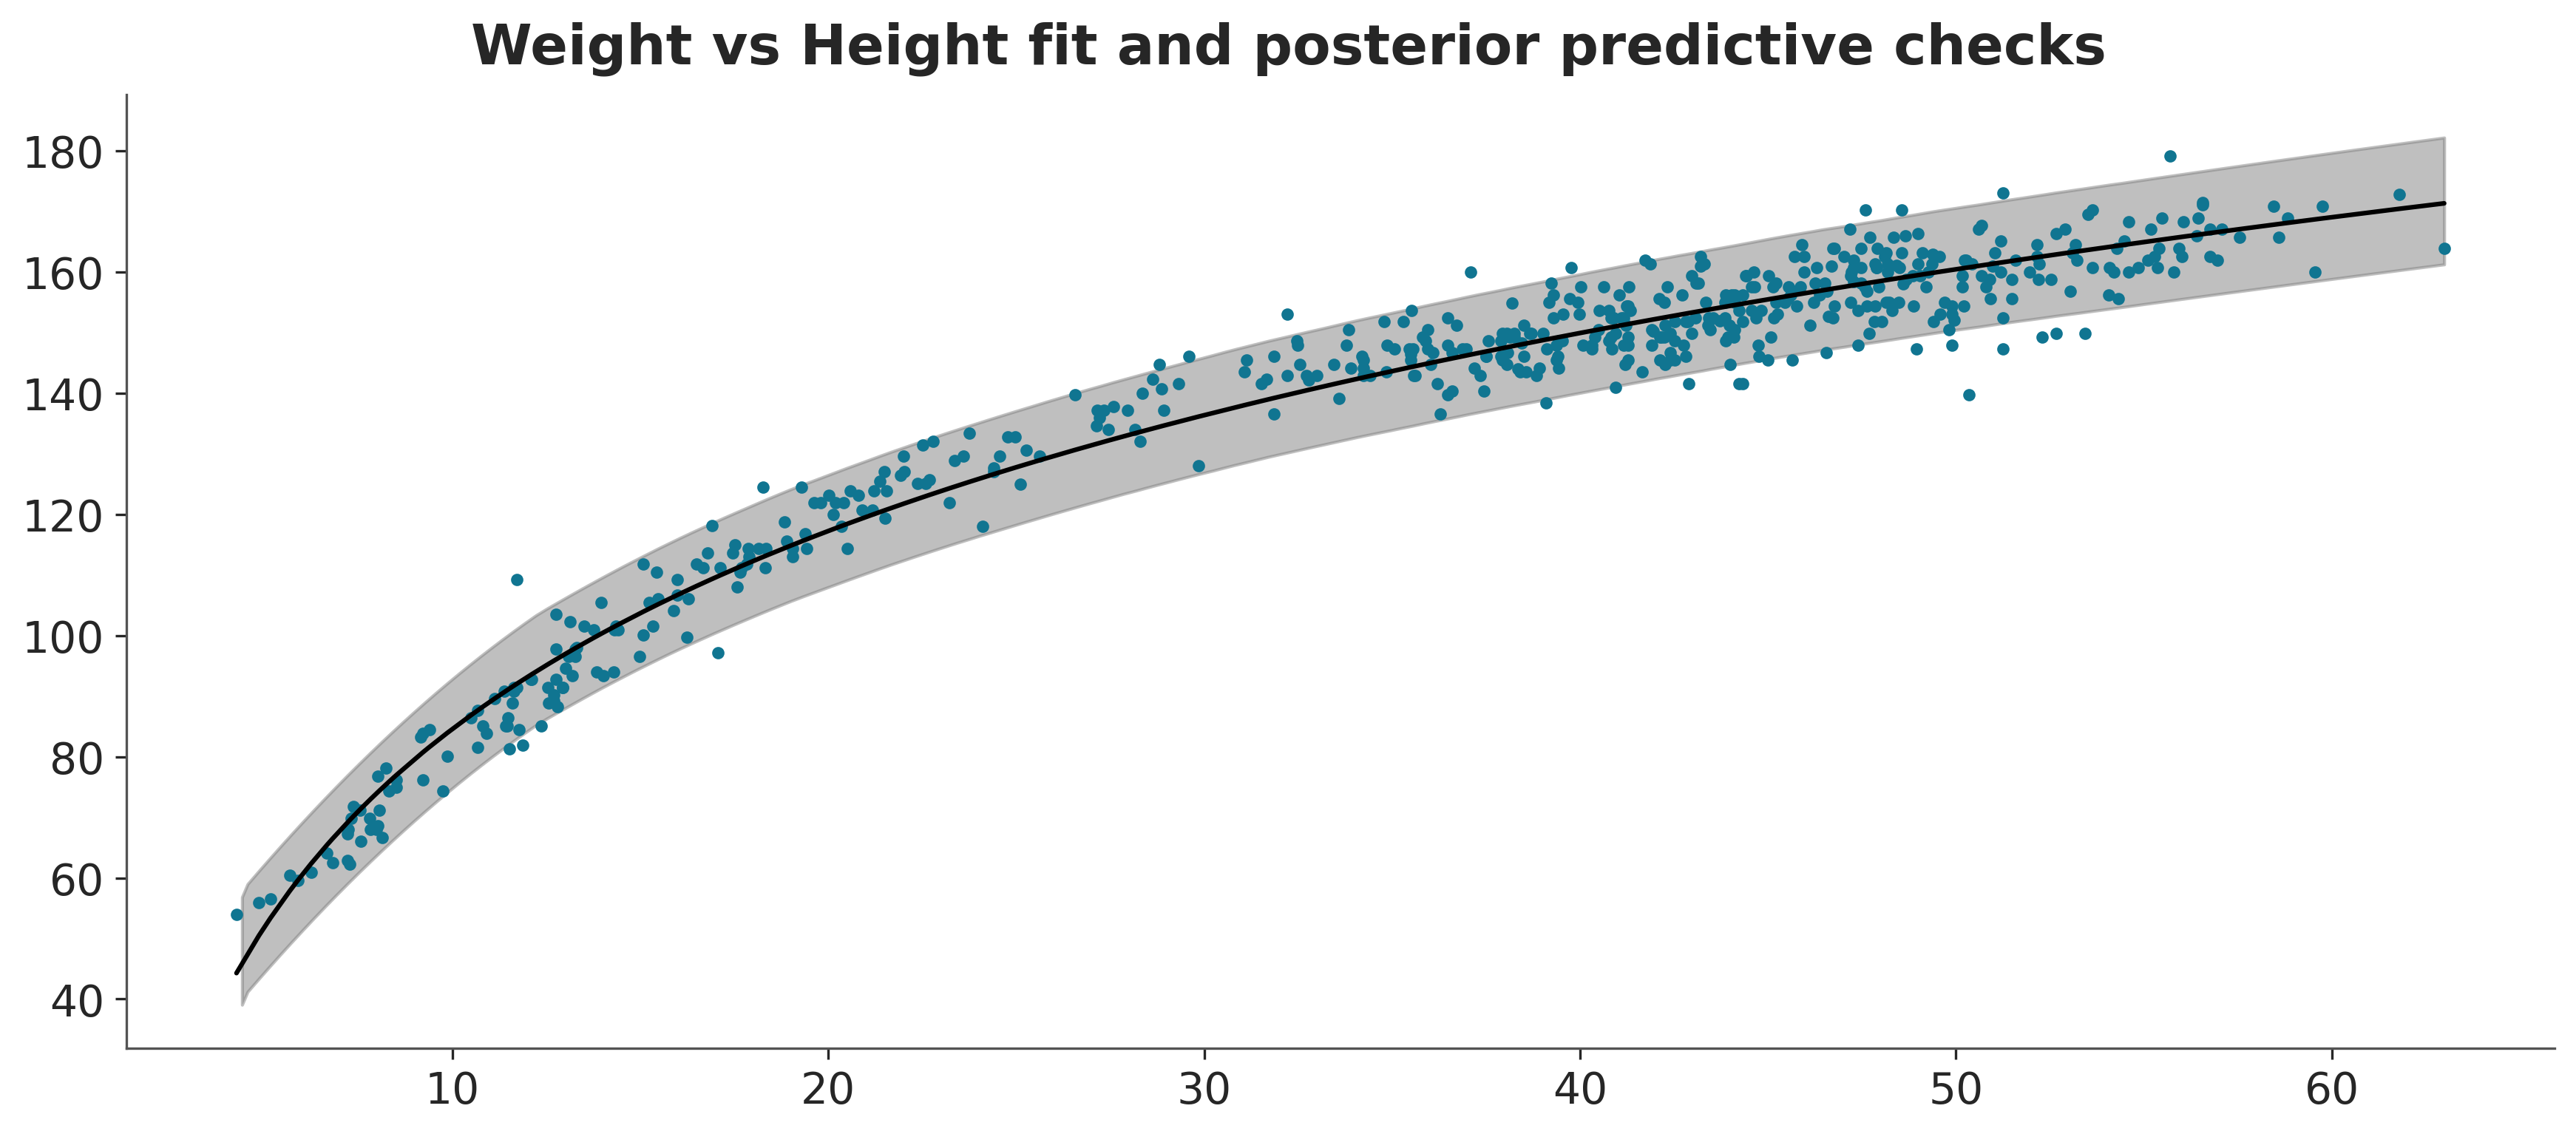

In [113]:
fig, ax = plt.subplots()

ax.plot(howell["weight"], howell["height"], "C0.")
posterior = az.extract(idata_heights, group="posterior")
pps = az.extract(idata_heights, group="posterior_predictive")["height_pred"]
mu_m = posterior["mu"].mean("sample")
order = np.argsort(howell["weight"].values)
ax.plot(howell["weight"][order], mu_m[order], c="k")


az.plot_hdi(howell["weight"], pps.T, color="gray")
fig.suptitle("Weight vs Height fit and posterior predictive checks");

In [114]:
posterior

<xarray.Dataset>
Dimensions:      (sample: 4000, mu_dim_0: 544, sigma_dim_0: 544)
Coordinates:
  * mu_dim_0     (mu_dim_0) int64 0 1 2 3 4 5 6 ... 537 538 539 540 541 542 543
  * sigma_dim_0  (sigma_dim_0) int64 0 1 2 3 4 5 6 ... 538 539 540 541 542 543
  * sample       (sample) object MultiIndex
  * chain        (sample) int64 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3 3
  * draw         (sample) int64 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    alpha        (sample) float64 -23.03 -24.96 -23.72 ... -22.66 -25.23 -20.3
    beta         (sample) float64 46.79 47.46 47.01 47.55 ... 46.72 47.54 46.17
    gamma        (sample) float64 3.81 4.298 4.624 4.732 ... 5.0 4.534 4.4 4.767
    delta        (sample) float64 0.02965 0.0286 0.0192 ... 0.01732 0.007892
    mu           (mu_dim_0, sample) float64 157.9 158.6 158.1 ... 163.1 162.6
    sigma        (sigma_dim_0, sample) float64 5.228 5.666 5.542 ... 5.31 5.181
Attributes:
    created_at:                 2025-04-18T09:13:55.478109
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              9.051993370056152
    tuning_steps:               1000

/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/plots/hdiplot.py:160: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


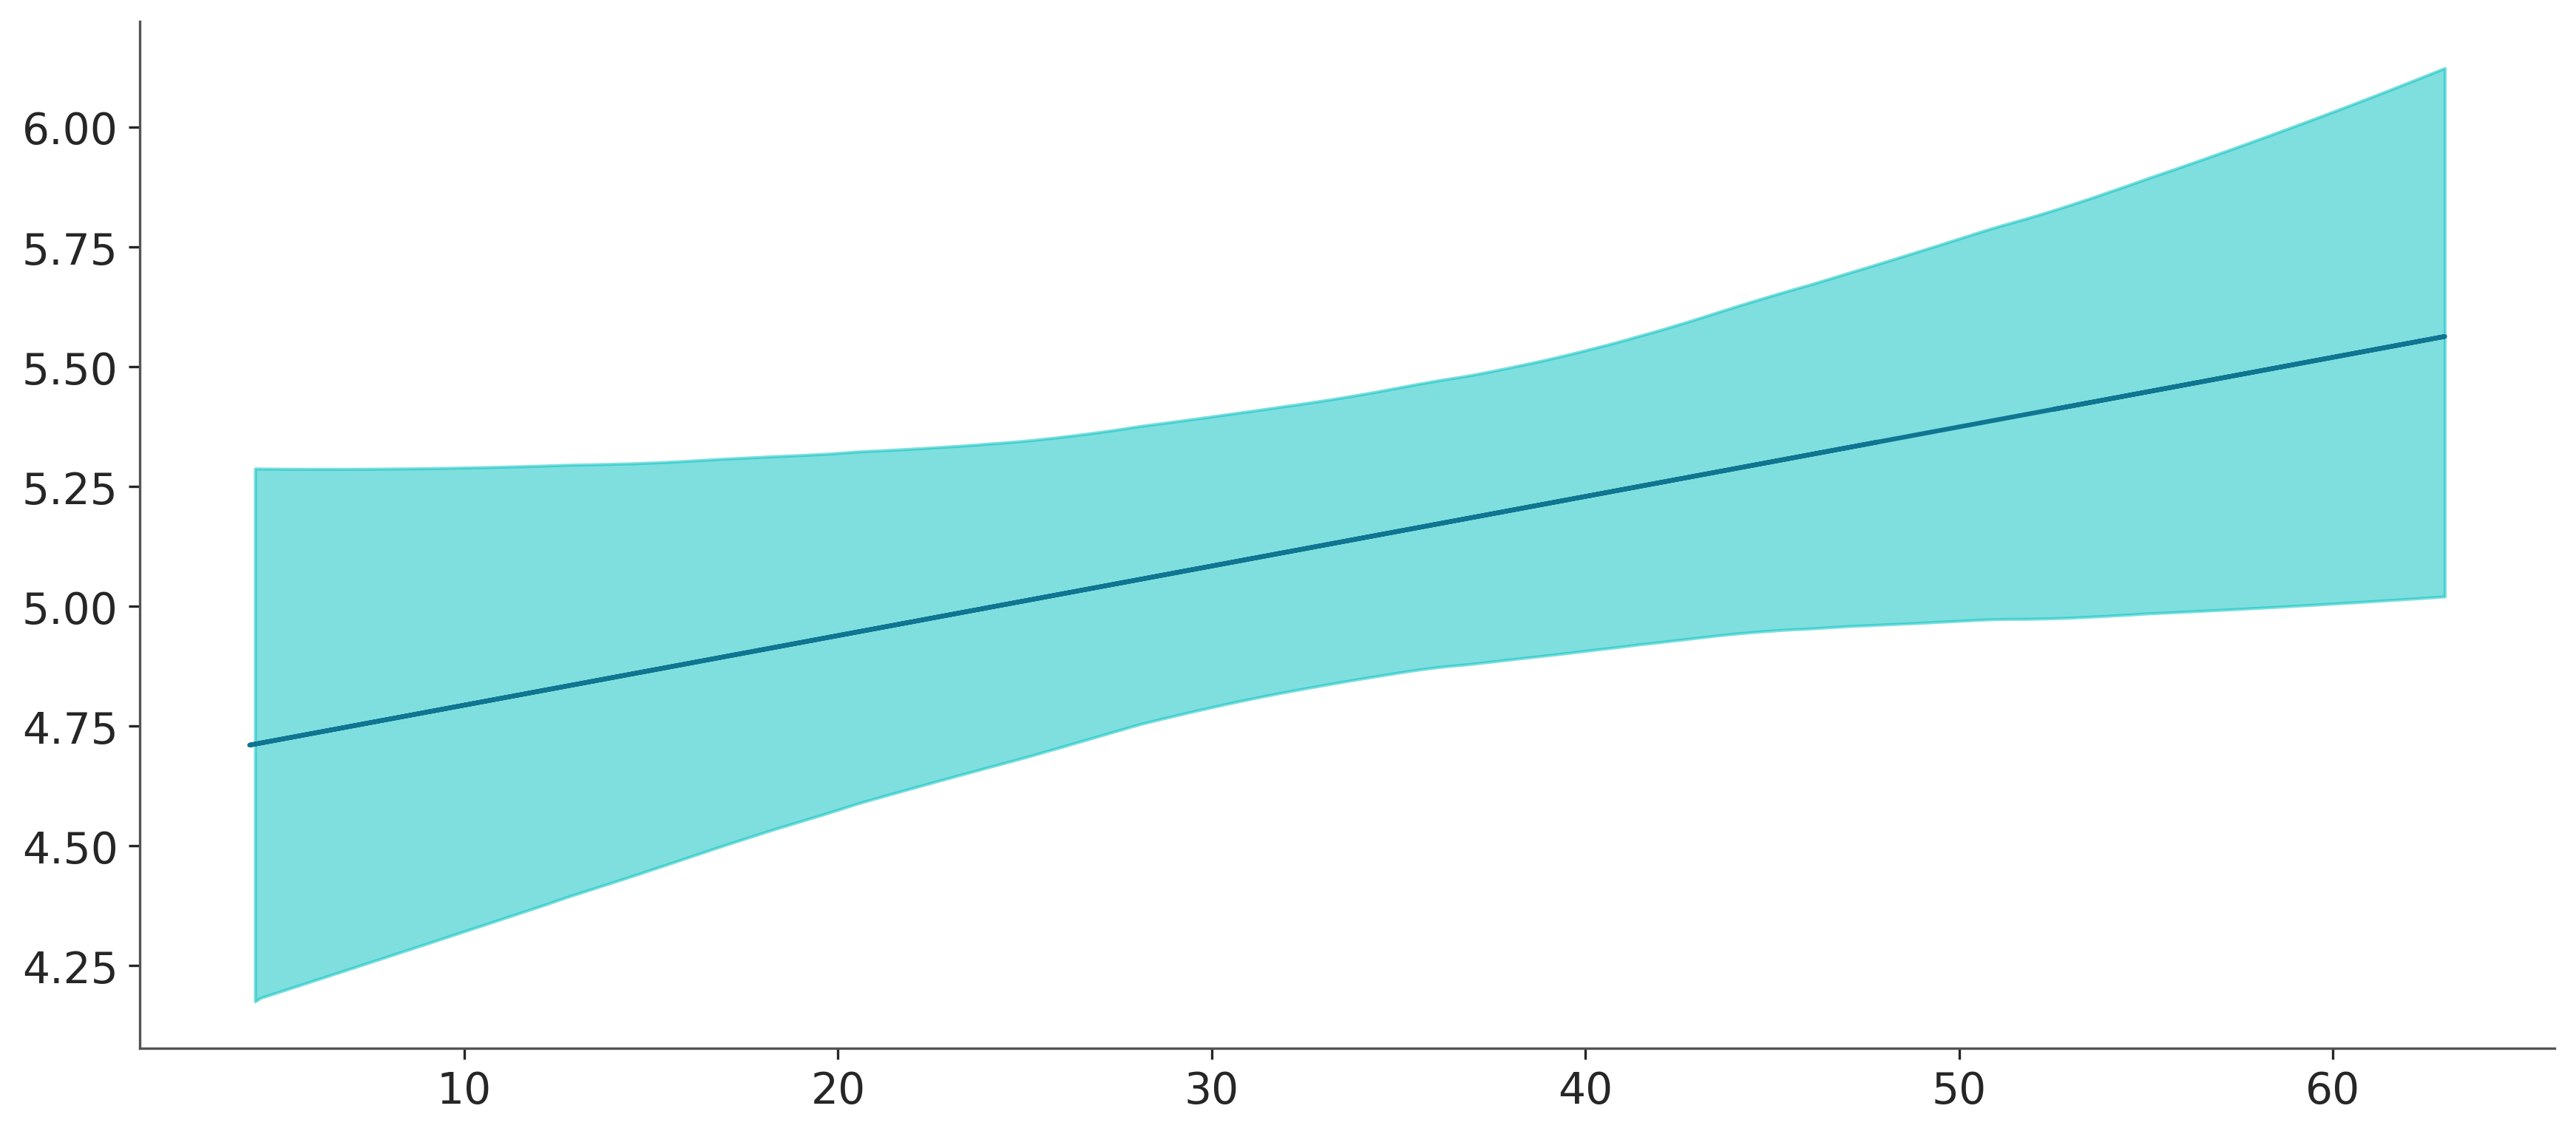

In [117]:
fig, ax = plt.subplots()
ax.plot(howell["weight"], posterior["sigma"].mean("sample"))
az.plot_hdi(howell["weight"], posterior["sigma"].T);